# Лабораторная работа №2. Просодика

**Курс «Синтез речи», Университет ИТМО**

Отчёт по предсказанию мест и длительности пауз на корпусе RUSLAN: разведочный анализ разметки MFA, подготовка данных, предиктор пауз и его качество.

**Критерии приёмки.** В README лабораторной указано **F1 ≥ 0,8** и **MAE ≤ 0,1 с**.
Позднее пересмотрены на менее жёсткие: **F1 ≥ 0,7 и MAE < 0,12 с** (на `test`, без последних слов фраз). Все выводы ниже сверяются с обновлёнными порогами, а причины высоких абсолютных ошибок разобраны отдельным разделом.

In [ ]:
import contextlib
import csv
import io
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture

from prepare_training_data import read_text_grids

RUSLAN_META = "../../data/metadata_RUSLAN_22200_normalized.csv"
ALIGN_DIR = "../../data/RUSLAN_align_v2/"
PAUSE_CSV = "data/RUSLAN_pause_metadata.csv"
CACHE = "data/cache_textgrids.pkl"

# Гласные из алфавита фонем MFA (common/phones_mfa.txt)
VOWELS = set("a e i o u æ ɐ ə ɛ ɨ ɪ ɵ ʉ ʊ".split())

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
BLUE, ORANGE, GREEN, RED = "#4C72B0", "#DD8452", "#55A868", "#C44E52"

## 1. Данные и разметка

Используются три источника:

1. `data/metadata_RUSLAN_22200_normalized.csv` - результат лабораторной №1 (`id | raw | nrm`), 21 854 фразы;
2. `data/RUSLAN_align_v2/*.TextGrid` - выравнивание MFA (Montreal Forced Aligner, русская модель v3.1.0).
   В каждом файле: `words` (слова и интервалы тишины, у тишины пустая метка) и `phones` (фонемы);
3. `labs/lab2_pauses/data/RUSLAN_pause_metadata.csv` - таблица «одна строка = одно слово», собранная скриптом `prepare_training_data.py` (формат из задания).

Читаем TextGrid функцией `read_text_grids` из приложенного скрипта. Результат кэшируем в pickle, чтобы не разбирать 22 тыс. файлов при каждом запуске.

In [ ]:
ruslan = pd.read_csv(RUSLAN_META, sep="|", names=["id", "raw", "nrm"], quoting=csv.QUOTE_NONE)

if Path(CACHE).exists():
    words_all, phones_all, _ = pickle.load(open(CACHE, "rb"))
else:
    words_all, phones_all, phoneme_seqs = read_text_grids(ruslan, ALIGN_DIR)
    pickle.dump((words_all, phones_all, phoneme_seqs), open(CACHE, "wb"))

pause_df = pd.read_csv(PAUSE_CSV, sep="|", quoting=csv.QUOTE_NONE)

n_textgrids = len(list(Path(ALIGN_DIR).glob("*.TextGrid")))
print(f"Фраз в метаданных (после лабы 1): {len(ruslan)}")
print(f"TextGrid-файлов в разметке: {n_textgrids}")
print(f"Фраз, для которых прочитан TextGrid: {words_all.id.nunique()}")
print(f"Фраз в таблице для предиктора пауз: {pause_df.id.nunique()}")
print(f"Слов в таблице: {len(pause_df)}; train: {(pause_df.set == 'train').sum()}, test: {(pause_df.set == 'test').sum()}")
pause_df.head(10)

Фраз в метаданных (после лабы 1):      21854
TextGrid-файлов в разметке:            22199
Фраз, для которых прочитан TextGrid:   21853
Фраз в таблице для предиктора пауз:    21570
Слов в таблице: 247787; train: 198343, test: 49444


,label,duration,id,label_raw,is_last_word,is_pause_after,pause_duration,set
0,с,0.11,000000_RUSLAN,С,0,0,0.000000,test
1,тревожным,0.58,000000_RUSLAN,тревожным,0,0,0.000000,test
2,чувством,0.62,000000_RUSLAN,чувством,0,0,0.000000,test
3,берусь,0.39,000000_RUSLAN,берусь,0,0,0.000000,test
4,я,0.09,000000_RUSLAN,я,0,0,0.000000,test
5,за,0.13,000000_RUSLAN,за,0,0,0.000000,test
6,перо,0.29,000000_RUSLAN,перо.,1,1,0.034762,test
7,кого,0.43,000001_RUSLAN,Кого,0,1,0.030000,train
8,интересуют,0.69,000001_RUSLAN,интересуют,0,0,0.000000,train
9,признания,0.58,000001_RUSLAN,признания,0,0,0.000000,train


Столбец `is_last_word` и пауза после последнего слова нужны только для полноты: по заданию их нельзя использовать
для обучения и оценки - это стык аудиофайлов при записи, а не естественная пауза. Во всём анализе ниже
«паузой внутри фразы» называется пауза после слова с `is_last_word == 0`.

## 2. Разведочный анализ

### 2.1. Средние длительности

- **Пауза** - интервал тишины между двумя словами внутри фразы (из таблицы `pause_df`).
- **Слово** - интервал слова в ярусе `words`.
- **Буква** - длительность слова, делённая на число букв в нём. Считаем двумя способами: среднее по словам
  («типичное слово») и отношение суммарной длительности к суммарному числу букв («средняя буква корпуса»).
- **Гласный / согласный** - интервалы яруса `phones`, гласные определены по алфавиту фонем MFA.
  Ударность в разметке не размечена, поэтому ударные и безударные гласные усреднены вместе.

In [ ]:
word_int = words_all[words_all.label != ""].copy()
word_int["n_letters"] = word_int.label.str.count(r"[а-яёa-z]")
word_int = word_int[word_int.n_letters > 0]
word_int["per_letter"] = word_int.duration / word_int.n_letters

phn = phones_all[~phones_all.label.isin(["<SIL>", "spn"])]
vowel_dur = phn[phn.label.isin(VOWELS)].duration
cons_dur = phn[~phn.label.isin(VOWELS)].duration

inner = pause_df[(pause_df.is_last_word == 0) & (pause_df.is_pause_after == 1)]
pause_dur = inner.pause_duration

def describe(name, s):
    return {"объект": name, "N": len(s), "среднее, мс": s.mean() * 1000, "медиана, мс": s.median() * 1000,
            "std, мс": s.std() * 1000, "5%, мс": s.quantile(.05) * 1000, "95%, мс": s.quantile(.95) * 1000}

letter_corpus = word_int.duration.sum() / word_int.n_letters.sum()
stats = pd.DataFrame([
    describe("пауза внутри фразы", pause_dur),
    describe("слово", word_int.duration),
    describe("буква (среднее по словам)", word_int.per_letter),
    describe("гласный", vowel_dur),
    describe("согласный", cons_dur),
]).set_index("объект").round(1)
print(f"Буква, отношение сумм по корпусу: {letter_corpus * 1000:.1f} мс")
print(f"Общая длительность разметки: {words_all.duration.sum() / 3600:.2f} ч")
stats

Буква, отношение сумм по корпусу: 72.5 мс
Общая длительность разметки: 31.02 ч


,N,"среднее, мс","медиана, мс","std, мс","5%, мс","95%, мс"
объект,,,,,,
пауза внутри фразы,46949,159.9,100.0,150.4,30.0,480.0
слово,251703,409.9,410.0,223.7,80.0,770.0
буква (среднее по словам),251703,77.3,71.4,29.7,48.9,126.0
гласный,595338,56.4,50.0,47.8,10.0,120.0
согласный,807022,84.8,80.0,37.1,30.0,150.0


In [4]:
# Квантование длительностей: MFA работает с шагом 10 мс, поэтому значения лежат на сетке
def share(s, v, tol=1e-6):
    return (abs(s - v) < tol).mean()

print(f"Гласных ровно 10 мс:        {share(vowel_dur, 0.01):.1%}  (медиана без них: {vowel_dur[vowel_dur > 0.011].median() * 1000:.0f} мс, среднее: {vowel_dur[vowel_dur > 0.011].mean() * 1000:.1f} мс)")
print(f"Согласных ровно 10 мс:      {share(cons_dur, 0.01):.2%}")
print(f"Пауз внутри фразы ровно 30 мс: {share(pause_dur, 0.03, 0.0005):.1%}")
print(f"Слов короче 50 мс:          {(word_int.duration < 0.05).mean():.2%}")

Гласных ровно 10 мс:        22.8%  (медиана без них: 60 мс, среднее: 70.2 мс)
Согласных ровно 10 мс:      0.19%
Пауз внутри фразы ровно 30 мс: 22.5%
Слов короче 50 мс:          1.88%


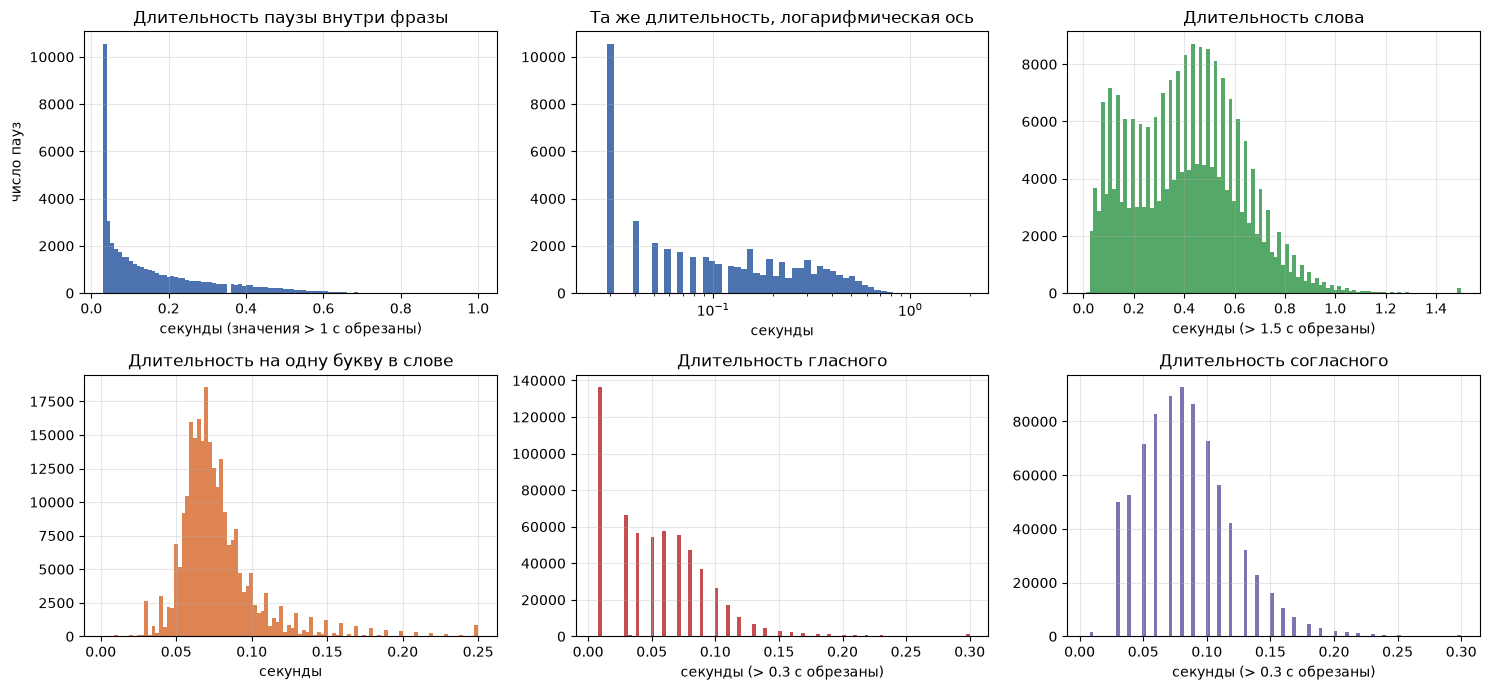

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

axes[0, 0].hist(pause_dur.clip(upper=1.0), bins=100, color=BLUE)
axes[0, 0].set(title="Длительность паузы внутри фразы", xlabel="секунды (значения > 1 с обрезаны)", ylabel="число пауз")

bins = np.logspace(np.log10(0.025), np.log10(2), 60)
axes[0, 1].hist(pause_dur, bins=bins, color=BLUE)
axes[0, 1].set_xscale("log")
axes[0, 1].set(title="Та же длительность, логарифмическая ось", xlabel="секунды")

axes[0, 2].hist(word_int.duration.clip(upper=1.5), bins=100, color=GREEN)
axes[0, 2].set(title="Длительность слова", xlabel="секунды (> 1.5 с обрезаны)")

axes[1, 0].hist(word_int.per_letter.clip(upper=0.25), bins=100, color=ORANGE)
axes[1, 0].set(title="Длительность на одну букву в слове", xlabel="секунды")

axes[1, 1].hist(vowel_dur.clip(upper=0.3), bins=100, color=RED)
axes[1, 1].set(title="Длительность гласного", xlabel="секунды (> 0.3 с обрезаны)")

axes[1, 2].hist(cons_dur.clip(upper=0.3), bins=100, color="#8172B3")
axes[1, 2].set(title="Длительность согласного", xlabel="секунды (> 0.3 с обрезаны)")

plt.tight_layout()
plt.show()

**Наблюдения.**

- Средняя **пауза внутри фразы - 160 мс**, медиана 100 мс, 95-й процентиль 480 мс: распределение с тяжёлым правым хвостом.
- Среднее **слово - 410 мс**, **буква - 77 мс** (по словам; 72,5 мс по корпусу в целом), что соответствует скорости
  речи около 13,7 букв в секунду - быстрой разговорной.
- **Гласные короче согласных** (среднее 56 против 85 мс): типично для русского, где безударные гласные сильно редуцируются.
  Но среднее по гласным сильно занижено: **22,8 % гласных имеют длительность ровно 10 мс** - это минимальный шаг разметки MFA,
  то есть, по сути, «гласный не нашли, но фонему надо куда-то поставить». Без них среднее 70 мс, медиана 60 мс.
- Все длительности лежат на сетке 10 мс (гребёнка на гистограммах). Это ограничение разметки, а не свойство речи, и оно
  определяет, какой точности предсказания длительности вообще имеет смысл добиваться.

### 2.2. Классы пауз по длительности

В гистограмме паузы видно сильный пик на минимальной длительности. Проверим, насколько он велик, и посмотрим
на самые частые значения.

In [6]:
vc = pause_dur.round(2).value_counts().sort_index()
top = vc.head(10).rename("число пауз").to_frame()
top["доля, %"] = (top["число пауз"] / len(pause_dur) * 100).round(1)
top.index.name = "длительность, с"
print(f"Всего пауз внутри фраз: {len(pause_dur)}; минимум: {pause_dur.min():.3f} с")
top

Всего пауз внутри фраз: 46949; минимум: 0.030 с


,число пауз,"доля, %"
"длительность, с",,
0.03,10553,22.5
0.04,3059,6.5
0.05,2120,4.5
0.06,1888,4.0
0.07,1729,3.7
0.08,1529,3.3
0.09,1527,3.3
0.10,1362,2.9
0.11,1239,2.6


In [7]:
x = np.log10(pause_dur.values).reshape(-1, 1)
gmm = GaussianMixture(n_components=3, random_state=0, n_init=3).fit(x)
order = np.argsort(gmm.means_.ravel())
gmm_table = pd.DataFrame({
    "вес, %": (gmm.weights_[order] * 100).round(1),
    "центр, с": (10 ** gmm.means_.ravel()[order]).round(3),
    "интервал ±1σ, с": [f"{10 ** (m - s):.3f}–{10 ** (m + s):.3f}"
                        for m, s in zip(gmm.means_.ravel()[order], np.sqrt(gmm.covariances_.ravel()[order]))],
}, index=["компонента 1", "компонента 2", "компонента 3"])
gmm_table

,"вес, %","центр, с","интервал ±1σ, с"
компонента 1,22.5,0.030,0.030–0.030
компонента 2,42.3,0.083,0.050–0.138
компонента 3,35.2,0.293,0.191–0.451


In [ ]:
# Длительность пауз в зависимости от того, какая пунктуация стоит после слова (label_raw включает знаки после слова)
def punct_class(tok):
    tok = str(tok)
    if re.search(r"[.!?…]", tok):
        return "конец предложения (. ! ? …)"
    if re.search(r"[,;:]", tok):
        return "запятая / ; / :"
    if re.search(r"[-–]|(?<!\w)-|-(?!\w)", tok):
        return "тире"
    if re.search(r"[«»\"'“”„()]", tok):
        return "кавычки / скобки"
    return "нет знака"

mid = pause_df[pause_df.is_last_word == 0].copy()
mid["punct"] = mid.label_raw.map(punct_class)
order_p = ["конец предложения (. ! ? …)", "запятая / ; / :", "тире", "кавычки / скобки", "нет знака"]
by_p = mid.groupby("punct").agg(слов=("is_pause_after", "size"), доля_пауз=("is_pause_after", "mean")).loc[order_p]
dur_p = mid[mid.is_pause_after == 1].groupby("punct").pause_duration.agg(["mean", "median"]).loc[order_p]
by_p["средняя пауза, мс"] = dur_p["mean"] * 1000
by_p["медиана паузы, мс"] = dur_p["median"] * 1000
by_p["доля пауз ≤ 50 мс"] = mid[(mid.is_pause_after == 1)].groupby("punct").pause_duration.apply(lambda s: (s <= 0.05).mean()).loc[order_p]
by_p.round(3)

,слов,доля_пауз,"средняя пауза, мс","медиана паузы, мс",доля пауз ≤ 50 мс
punct,,,,,
конец предложения (. ! ? …),20473,0.945,209.762,170.0,0.155
запятая / ; / :,20321,0.543,149.483,90.0,0.352
тире,5567,0.465,188.541,130.0,0.263
кавычки / скобки,1738,0.441,179.935,120.0,0.284
нет знака,178118,0.074,88.950,40.0,0.565


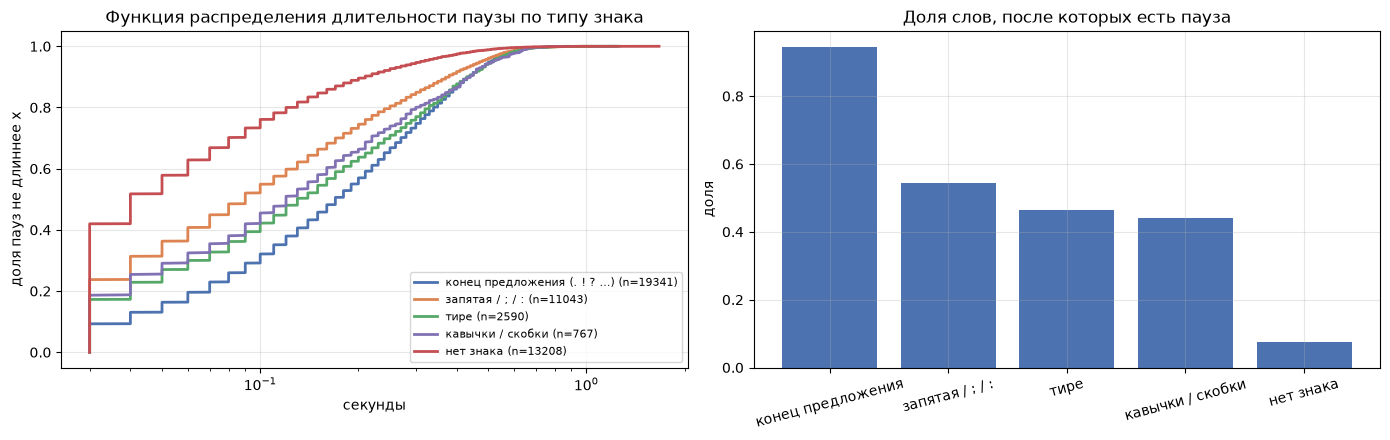

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, color in zip(order_p, [BLUE, ORANGE, GREEN, "#8172B3", RED]):
    s = np.sort(mid[(mid.punct == name) & (mid.is_pause_after == 1)].pause_duration.values)
    if len(s) > 50:
        axes[0].plot(s, np.arange(1, len(s) + 1) / len(s), color=color, linewidth=2, label=f"{name} (n={len(s)})")
axes[0].set_xscale("log")
axes[0].set(title="Функция распределения длительности паузы по типу знака", xlabel="секунды", ylabel="доля пауз не длиннее x")
axes[0].legend(fontsize=8)

axes[1].bar(range(len(order_p)), by_p["доля_пауз"], color=BLUE)
axes[1].set_xticks(range(len(order_p)))
axes[1].set_xticklabels([n.split(" (")[0] for n in order_p], rotation=15)
axes[1].set(title="Доля слов, после которых есть пауза", ylabel="доля")
plt.tight_layout()
plt.show()

**Классы пауз.** Три компоненты гауссовой смеси по логарифму длительности хорошо согласуются с эмпирической картиной:

| Класс | Длительность | Доля пауз | Что это, по данным |
|---|---|---|---|
| **Микропаузы** | ровно 30 мс | 22,5 % | нижняя граница интервала тишины в MFA; см. проверку по сигналу ниже |
| **Короткие** | 50–140 мс (центр ≈ 80 мс) | 42 % | внутрифразовые границы: запятые, границы синтагм |
| **Длинные** | 190–450 мс (центр ≈ 290 мс) | 35 % | границы предложений и крупных синтагм |

Пунктуация сильно разделяет эти классы: после `. ! ? …` пауза есть в **94,5 %** случаев (медиана 170 мс),
после запятой - в 54 % (медиана 90 мс), после тире - в 47 %, после слова без знака - всего в 7,4 %.
Но **57 % пауз без знака препинания - это микропаузы ≤ 50 мс**, а среди пауз после запятой таких 35 %.

### 2.3. Где появляются паузы и насколько это логично

In [ ]:
mid = pause_df.copy()
mid["punct"] = mid.label_raw.map(punct_class)
mid["next_label"] = mid.groupby("id").label.shift(-1)
mid["prev_label"] = mid.groupby("id").label.shift(1)
mid["idx"] = mid.groupby("id").cumcount()
mid["n_words"] = mid.groupby("id").label.transform("size")
mid["rel_pos"] = mid.idx / (mid.n_words - 1).clip(lower=1)
mid = mid[mid.is_last_word == 0]

no_punct = mid[mid.punct == "нет знака"]
print("Паузы БЕЗ знака препинания - слово, которое идёт ПОСЛЕ паузы:")
nxt = no_punct[no_punct.is_pause_after == 1].next_label.value_counts().head(15)
base = no_punct.next_label.value_counts()
pd.DataFrame({"после паузы": nxt, "всего таких слов после слов без знака": base.reindex(nxt.index),
              "доля с паузой перед ним": (nxt / base.reindex(nxt.index)).round(2)})

Паузы БЕЗ знака препинания — слово, которое идёт ПОСЛЕ паузы:


,после паузы,всего таких слов после слов без знака,доля с паузой перед ним
next_label,,,
и,1557,5058,0.31
в,406,4664,0.09
не,310,3051,0.10
я,209,2024,0.10
на,171,2552,0.07
он,168,904,0.19
с,163,1813,0.09
о,142,615,0.23
у,130,838,0.16


In [11]:
print("Запятые, после которых паузы НЕТ: доля и примеры")
comma = mid[mid.punct == "запятая / ; / :"]
print(f"без паузы: {(comma.is_pause_after == 0).mean():.1%} из {len(comma)}")
# Контекст: слово с запятой и следующее слово
samples = comma[comma.is_pause_after == 0].sample(12, random_state=1)
pd.DataFrame({"id": samples.id, "токен": samples.label_raw, "следующее слово": samples.next_label}).reset_index(drop=True)

Запятые, после которых паузы НЕТ: доля и примеры
без паузы: 45.7% из 20321


,id,токен,следующее слово
0,011565_RUSLAN,"Баранов,",еселевский
1,004141_RUSLAN,"казалось,",что
2,006470_RUSLAN,"провинции,",есть
3,018388_RUSLAN,"Станиславского,",халиф
4,009977_RUSLAN,"чувствую,",то
5,012256_RUSLAN,"жить,",либо
6,017668_RUSLAN,"спортивные,",хорошо
7,009863_RUSLAN,"голос,",шепнул
8,015189_RUSLAN,"мнение,",что
9,014713_RUSLAN,"узнал,",что


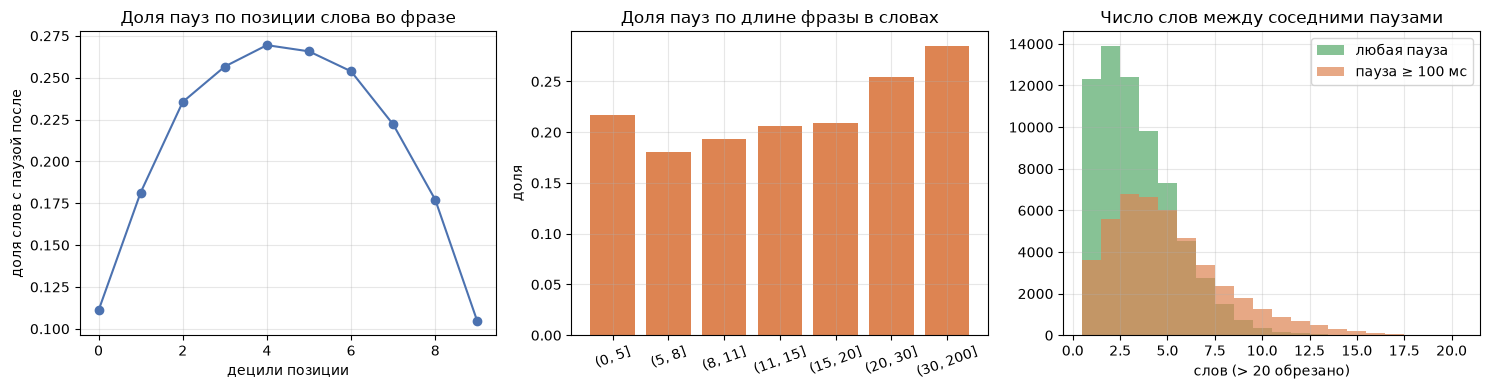

Слов между паузами: любая пауза — среднее 3.43, медиана 3; пауза ≥ 100 мс — среднее 5.04, медиана 4


In [ ]:
# Доля пауз по относительной позиции слова во фразе и по длине фразы
mid["pos_bin"] = pd.cut(mid.rel_pos, bins=np.linspace(0, 1, 11), include_lowest=True)
mid["len_bin"] = pd.cut(mid.n_words, bins=[0, 5, 8, 11, 15, 20, 30, 200])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
g = mid.groupby("pos_bin", observed=True).is_pause_after.mean()
axes[0].plot(range(len(g)), g.values, marker="o", color=BLUE)
axes[0].set(title="Доля пауз по позиции слова во фразе", xlabel="децили позиции", ylabel="доля слов с паузой после")

g = mid.groupby("len_bin", observed=True).is_pause_after.mean()
axes[1].bar(range(len(g)), g.values, color=ORANGE)
axes[1].set_xticks(range(len(g)))
axes[1].set_xticklabels([str(i) for i in g.index], rotation=20)
axes[1].set(title="Доля пауз по длине фразы в словах", ylabel="доля")

# Длина «фразы между паузами»
def phrase_lengths(min_pause):
    seg = mid.copy()
    seg["cut"] = ((seg.is_pause_after == 1) & (seg.pause_duration >= min_pause)).astype(int)
    seg["phrase"] = seg.groupby("id").cut.transform(lambda s: s.shift(fill_value=0).cumsum())
    return seg.groupby(["id", "phrase"]).size()

len_all, len_100 = phrase_lengths(0.0), phrase_lengths(0.1)
bins_ = np.arange(0.5, 21.5)
axes[2].hist(len_all.clip(upper=20), bins=bins_, alpha=0.7, color=GREEN, label="любая пауза")
axes[2].hist(len_100.clip(upper=20), bins=bins_, alpha=0.7, color=ORANGE, label="пауза ≥ 100 мс")
axes[2].set(title="Число слов между соседними паузами", xlabel="слов (> 20 обрезано)")
axes[2].legend()
plt.tight_layout()
plt.show()
print(f"Слов между паузами: любая пауза - среднее {len_all.mean():.2f}, медиана {len_all.median():.0f}; "
      f"пауза ≥ 100 мс - среднее {len_100.mean():.2f}, медиана {len_100.median():.0f}")

**Насколько паузы логичны.**

- **Пауза без знака препинания** чаще всего стоит перед **союзами**: перед «и» - в 31 % случаев (1557 раз), перед «или» - в 38 %, заметно чаще среднего перед «он» (19 %) и «о» (23 %). Перед предлогами «в», «на», «с» - лишь 7–9 %, то есть на уровне «фона».
  Это лингвистически разумно: слово «и» открывает новую синтагму, а предлог с существительным читается слитно.
- **46 % запятых не сопровождаются паузой.** В примерах видно, что диктор часто не отделяет паузой придаточное «что/то/либо» от предшествующего слова («казалось, что», «узнал, что», «мнение, что»). Значит, запятая - не надёжный признак паузы, а признаки для модели должны учитывать следующее слово.
- **Позиция во фразе:** доля пауз колоколообразна - 11 % в первом дециле фразы, максимум ≈ 27 % в середине, и снова ≈ 10 % в последнем дециле. В конце фразы паузы редки, потому что последнее слово и так завершает высказывание.
- **Длина фразы:** в самых длинных фразах (> 20 слов) пауз больше (25–28 % против 18–21 % в коротких).
- Средняя длина «отрезка» между паузами - **3,4 слова**, а если учитывать только паузы ≥ 100 мс, то **5,0 слов** (медиана 4). Это типичный размер.

### 2.4. Качество разметки

In [13]:
# Повторяем предобработку main() prepare_training_data.py, чтобы найти фразы, которые не удалось привязать к тексту
meta = ruslan.copy()
for ch, rep in [("‐", "-"), ("‑", "-"), ("’", "'")]:
    meta["nrm"] = meta.nrm.str.replace(ch, rep)
meta["nrm"] = meta.nrm.str.replace(r"\((.*?)\)", "[bracketed]", regex=True).str.replace(r"\<(.*?)\>", "[bracketed]", regex=True)
w_fix = words_all.copy()
w_fix["label"] = w_fix.label.str.replace("‐", "-").str.replace("‑", "-")
by_id = {k: g.label.tolist() for k, g in w_fix.groupby("id")}

def first_mismatch(text, labels):
    low = text.lower()
    for lab in labels:
        if lab == "":
            continue
        parts = low.split(lab, maxsplit=1)
        if len(parts) == 1:
            return lab
        low = parts[1]
    return None

bad = []
for uid, nrm in meta[["id", "nrm"]].values:
    labs = by_id.get(uid)
    if labs is None:
        bad.append((uid, None, nrm, "нет TextGrid"))
        continue
    lab = first_mismatch(nrm, labs)
    if lab is not None:
        bad.append((uid, lab, nrm, "слово из TextGrid не найдено в тексте"))
bad = pd.DataFrame(bad, columns=["id", "слово MFA", "nrm", "причина"])
print(f"Не удалось привязать к тексту: {len(bad)} из {len(meta)} фраз ({len(bad) / len(meta):.2%})")
print(bad.причина.value_counts().to_string())
bad["слово MFA"].value_counts().head(15)

Не удалось привязать к тексту: 284 из 21854 фраз (1.30%)
причина
слово из TextGrid не найдено в тексте    283
нет TextGrid                               1


слово MFA
[bracketed]      255
)                 11
(я                 2
/библиография      1
/например          1
(                  1
простодушие)       1
(тогда             1
(у                 1
(в                 1
(кстати            1
(она               1
(ведь              1
(первые            1
(тем               1
Name: count, dtype: int64

In [14]:
show = bad.head(8).copy()
show["nrm"] = show.nrm.str.slice(0, 100)
show

,id,слово MFA,nrm,причина
0,000880_RUSLAN,/библиография,Я на букву О библиография к Окуджаве.,слово из TextGrid не найдено в тексте
1,004530_RUSLAN,/например,"Например, вертухай, как вы соизволили дружески меня поименовать.",слово из TextGrid не найдено в тексте
2,005321_RUSLAN,NaN,Реакция Дроздова была совершенно неожиданной.,нет TextGrid
3,005846_RUSLAN,[bracketed],Дукель то есть Дукальский ставит через приезжих латышей. Это крутой солидняк.,слово из TextGrid не найдено в тексте
4,005893_RUSLAN,[bracketed],Один раз грузчики товарной станции им это удалось.,слово из TextGrid не найдено в тексте
5,005976_RUSLAN,[bracketed],"Женщинам, разумеется. Или почти всем. На всякий случай. Фраза недвусмысленная и безобидная при этом.",слово из TextGrid не найдено в тексте
6,006099_RUSLAN,[bracketed],"Гонорар вам, я знаю, это не безразлично двойной. С этого бы и начинали.",слово из TextGrid не найдено в тексте
7,006229_RUSLAN,[bracketed],"""Марина!"" с легким ужасом подумал я. Все знают, что ужас можно испытывать в едва ощутимой степени. З",слово из TextGrid не найдено в тексте


In [15]:
# Признаки сомнительной разметки
ph_spn = phones_all[phones_all.label == "spn"].groupby("id").size().rename("spn")
u = words_all.groupby("id").agg(total=("duration", "sum"))
u["n_letters"] = word_int.groupby("id").n_letters.sum()
u["speech"] = words_all[words_all.label != ""].groupby("id").duration.sum()
u["rate"] = u.n_letters / u.speech                    # букв в секунду речи
u["max_inner_sil"] = (words_all[words_all.label == ""].groupby("id").duration.max())
u["max_per_letter"] = word_int.groupby("id").per_letter.max()
u["spn"] = ph_spn
u["spn"] = u.spn.fillna(0)
u = u.fillna({"max_inner_sil": 0})

flags = pd.DataFrame({
    "есть фонема spn (слово не распознано)": u.spn > 0,
    "слово длиннее 0.5 с на букву": u.max_per_letter > 0.5,
    "тишина длиннее 1 с": u.max_inner_sil > 1.0,
    "скорость < 9 или > 18 букв/с": (u.rate < 9) | (u.rate > 18),
    "не привязана к тексту (см. выше)": u.index.isin(bad.id),
})
flags["любой признак"] = flags.any(axis=1)
summary = pd.DataFrame({"фраз": flags.sum(), "доля, %": (flags.mean() * 100).round(1)})
print("Скорость речи, букв/с:", u.rate.describe().round(2).to_dict())
summary

Скорость речи, букв/с: {'count': 21853.0, 'mean': 13.68, 'std': 1.59, 'min': 1.7, '25%': 12.81, '50%': 13.85, '75%': 14.73, 'max': 22.05}


,фраз,"доля, %"
есть фонема spn (слово не распознано),2253,10.3
слово длиннее 0.5 с на букву,29,0.1
тишина длиннее 1 с,64,0.3
скорость < 9 или > 18 букв/с,191,0.9
не привязана к тексту (см. выше),283,1.3
любой признак,2405,11.0


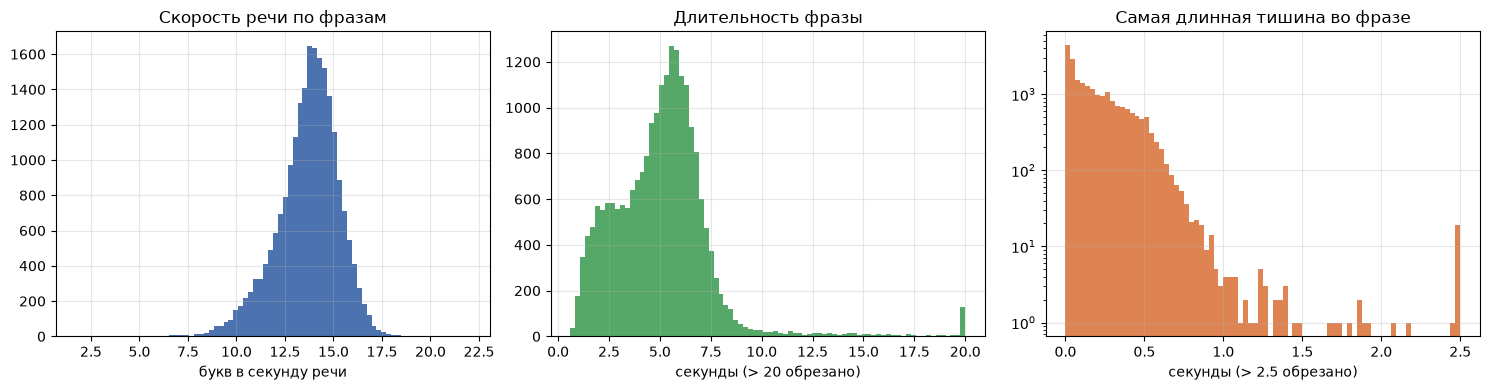

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(u.rate.clip(upper=25), bins=80, color=BLUE)
axes[0].set(title="Скорость речи по фразам", xlabel="букв в секунду речи")
axes[1].hist(u.total.clip(upper=20), bins=80, color=GREEN)
axes[1].set(title="Длительность фразы", xlabel="секунды (> 20 обрезано)")
axes[2].hist(u.max_inner_sil.clip(upper=2.5), bins=80, color=ORANGE)
axes[2].set_yscale("log")
axes[2].set(title="Самая длинная тишина во фразе", xlabel="секунды (> 2.5 обрезано)")
plt.tight_layout()
plt.show()

#### Реальны ли короткие «паузы»? Проверка по энергии сигнала

Пик на 30 мс подозрителен: на гистограмме он в десятки раз выше соседних значений. Проверим по самой
аудиозаписи. Для случайных пауз каждого класса длительности берём интервал из TextGrid (без краёв по 5 мс,
чтобы не захватить соседние звуки) и считаем его RMS в дБ относительно RMS речи той же фразы.
Если «пауза» - настоящая тишина, уровень должен быть заметно ниже речи (у длинных пауз - порядка −30…−40 дБ).

In [ ]:
from scipy.io import wavfile

WAV_DIR = Path("../../data/RUSLAN/RUSLAN")
w_ = words_all.copy()
w_["end"] = w_.groupby("id").duration.cumsum()
w_["start"] = w_.end - w_.duration
last_rows = w_.groupby("id").tail(1).index
sil = w_[(w_.label == "") & (w_.start > 0) & (~w_.index.isin(last_rows))]   # паузы внутри фразы

classes = {
    "30 мс": (0.025, 0.035), "40–60 мс": (0.035, 0.065), "60–100 мс": (0.065, 0.105),
    "100–200 мс": (0.105, 0.205), "> 300 мс": (0.3, 5.0),
}
rng = np.random.default_rng(0)
wav_cache = {}

def get_wav(uid):
    if uid not in wav_cache:
        sr, x = wavfile.read(WAV_DIR / f"{uid}.wav")
        wav_cache[uid] = (sr, x.astype(np.float64) / 32768.0)
    return wav_cache[uid]

def rms_db(seg, ref):
    return 20 * np.log10((np.sqrt(np.mean(seg ** 2)) + 1e-9) / ref)

rows = []
for cname, (lo, hi) in classes.items():
    pool = sil[(sil.duration >= lo) & (sil.duration < hi)]
    for _, r in pool.sample(min(300, len(pool)), random_state=0).iterrows():
        sr, x = get_wav(r.id)
        a, b = int((r.start + 0.005) * sr), int((r.end - 0.005) * sr)
        if b - a < 10:
            continue
        ref = np.sqrt(np.mean(x ** 2))             # RMS всей фразы - опорный уровень
        rows.append({"класс": cname, "дБ": rms_db(x[a:b], ref)})
    wav_cache.clear()
energy = pd.DataFrame(rows)
order_c = list(classes)
tab = energy.groupby("класс").дБ.describe(percentiles=[.25, .5, .75]).loc[order_c][["count", "25%", "50%", "75%"]].round(1)
tab["доля ярче −20 дБ"] = energy.groupby("класс").дБ.apply(lambda s: (s > -20).mean()).loc[order_c].round(2)
tab

,count,25%,50%,75%,доля ярче −20 дБ
класс,,,,,
30 мс,300.0,-33.2,-27.2,-21.4,0.20
40–60 мс,300.0,-40.3,-33.6,-26.8,0.09
60–100 мс,300.0,-43.5,-38.6,-31.8,0.04
100–200 мс,300.0,-43.9,-39.8,-33.8,0.02
> 300 мс,300.0,-47.4,-42.3,-35.7,0.03


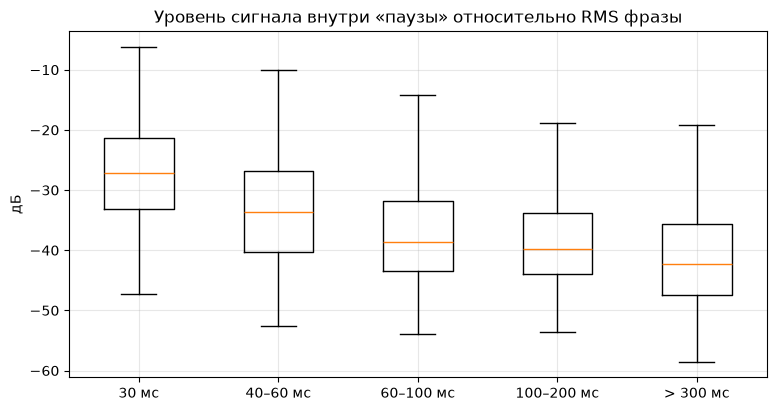

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot([energy[energy.класс == c].дБ for c in order_c], tick_labels=order_c, showfliers=False)
ax.set(title="Уровень сигнала внутри «паузы» относительно RMS фразы", ylabel="дБ")
plt.show()

**Вывод по проверке сигнала.** Паузы в 30 мс в медиане всего на −27 дБ ниже фразы, и **каждая пятая из них громче −20 дБ**,
то есть содержит звук. Для настоящих пауз ≥ 100 мс медиана −40 дБ, и громче −20 дБ лишь 2–4 %. Промежуточный класс
40–60 мс (9 % громче −20 дБ) - смешанный. Значит, значительная часть 30-миллисекундных «пауз» - **артефакт выравнивания**
(граница слов, где MFA вставил минимальный интервал тишины), а не пауза, которую услышит слушатель.

**Другие проблемы разметки:**

- **Фраз, не привязанных к тексту, - 284 (1,3 %)**: 283 из-за слова, которое не находится в нормализованном тексте, и одна без TextGrid.
  В 255 случаях это метка `[bracketed]`: разметка MFA построена по сырому тексту, где были круглые скобки
  (MFA записывает слова в скобках как `[bracketed]`), а нормализатор из лабы 1 скобки убрал. Результат - вся фраза
  выпадает из обучающей выборки, хотя выравнивание в ней нормальное.
- **10,3 % фраз (2253) содержат фонему `spn`** - MFA не смог распознать слово (обычно его нет в словаре), и время вокруг него размечено ненадёжно.
- Ещё ≈ 1 % фраз имеют неправдоподобную скорость речи (< 9 или > 18 букв/с), 29 - слово длиннее 0,5 с на букву
  (слова-«растяжки» из-за сбоя выравнивания), 64 - тишину дольше секунды. С учётом пересечений **«подозрительных» фраз - 11 %**.

#### Что потеряла нормализация из лабораторной №1

Разметка MFA строилась по сырому тексту, а таблица пауз собирается по нормализованному. Сравним, что изменил нормализатор
в знаках, которые несут информацию о паузах.

In [19]:
pairs = {
    "многоточие (.. / ... / …)": r"\.\.|…",
    "скобки ( ) < >": r"[()<>]",
    "слэш /": r"/",
}
raw_txt = ruslan.raw.astype(str)
nrm_txt = ruslan.nrm.astype(str)
pd.DataFrame({
    "в сыром тексте": {k: raw_txt.str.contains(v).sum() for k, v in pairs.items()},
    "в нормализованном": {k: nrm_txt.str.contains(v).sum() for k, v in pairs.items()},
})

,в сыром тексте,в нормализованном
многоточие (.. / ... / …),3643,3135
скобки ( ) < >,281,0
слэш /,3,0


Многоточия нормализатор в основном сохранил (3643 → 3135), но конструкции вроде `!..`, `?..` превратились в `!`, `?`:
информация о протяжённой паузе ушла. Скобки и слэши удалены полностью, хотя на аудио часть слов внутри них произнесена.

### 2.5. Потолок качества при текущей разметке

Целевая метрика - F1 для `is_pause_after`. Положительный класс включает и микропаузы. Оценим, какой F1 получит
**идеальный предсказатель, который не умеет находить паузы короче порога t** (то есть безошибочно угадывает все
паузы ≥ t и не ставит остальные). Точность у него 1, полнота равна доле пауз ≥ t.

In [ ]:
inner_all = pause_df[pause_df.is_last_word == 0]
total_pauses = inner_all.is_pause_after.sum()
rows = []
for t in [0.0, 0.035, 0.045, 0.055, 0.065, 0.105]:
    recall = (inner_all.pause_duration >= t).sum() / total_pauses if t > 0 else 1.0
    rows.append({"не находим паузы короче": f"{round(t * 1000)} мс" if t else "- (идеал)",
                 "полнота": recall, "F1 идеального предсказателя": 2 * recall / (1 + recall)})
pd.DataFrame(rows).round(3).set_index("не находим паузы короче")

,полнота,F1 идеального предсказателя
не находим паузы короче,,
— (идеал),1.000,1.000
35 мс,0.775,0.873
45 мс,0.710,0.830
55 мс,0.665,0.799
65 мс,0.625,0.769
105 мс,0.494,0.661


## Выводы по разведочному анализу

1. **Паузы - не бинарное явление.** Есть микропаузы 30 мс (22,5 %, значительная часть - артефакт MFA, не тишина), короткие (≈ 50–140 мс) и длинные (≈ 200–450 мс). Длительность зависит от типа знака: конец предложения ≈ 170 мс (медиана), запятая ≈ 90 мс, без знака ≈ 40 мс.
2. **Пунктуация - главный, но недостаточный признак**: после `. ! ? …` паузы почти всегда (94,5 %), после запятой - в 54 %, а 57 % пауз без знака - это микропаузы. Правило «пауза там, где есть знак» даёт, по грубой оценке, F1 ≈ 0,71 - ниже порога 0,8; нужны признаки следующего слова (союзы), позиции во фразе и синтаксиса.
3. **Потолок метрики задан разметкой.** Если не предсказывать паузы ≤ 50 мс, то даже идеальная модель остановится у F1 ≈ 0,80
   (таблица выше). Исходный порог 0,8 был на этой границе, новый порог 0,70 оставляет запас, но реальная модель не идеальна.  Поэтому, кроме официальной метрики на полной разметке, мы используем разрешение из задания и считае **метрику на «чистом» `test`**: без фраз с признаками плохой разметки и без слов, после которых «пауза» 30–50 мс. Это обосновано проверкой по сигналу выше.
4. **Обучающие данные стоит чистить**: ≈ 11 % фраз с признаками плохой разметки (из них 10 % - `spn`), ещё 1,3 % потеряно из-за скобок, которые убрал нормализатор. Часть потерь можно вернуть, сопоставляя `[bracketed]` со словами из скобок сырого текста или перезапустив выравнивание по нормализованному тексту (дополнительное задание 1).
5. **Длительности лежат на сетке 10 мс**, а точность на малых значениях ограничена самим выравниванием. Для MAE ≤ 100 мс это не препятствие: размах длинных пауз 190–450 мс, стандартное отклонение всех пауз 150 мс.

Следующие шаги: подготовка данных с учётом найденных проблем, бейзлайн по пунктуации и обучаемая модель.

## 3. Подготовка данных для предиктора пауз

Таблица `RUSLAN_pause_metadata.csv` собрана приложенным скриптом `prepare_training_data.py` в формате из задания
(`id | label | label_raw | duration | is_last_word | is_pause_after | pause_duration | set`) и **не изменялась**: это официальная разметка, по которой метрики считаются на полном `test`.

По итогам разведки принято четыре решения.

1. **Фразы, не привязанные к тексту, исключаются (284 из 21 854).** Причина почти всегда в скобках, которые убрал нормализатор (см. раздел 2.4). Скрипт их уже отбрасывает, так что в таблице их нет.
2. **Порог «настоящей» паузы - 60 мс.** Обучающая метка `y` = 1, если после слова пауза ≥ 60 мс; паузы 30–50 мс (по сигналу - в значительной части не тишина) считаются отсутствием паузы. Длительность `y_dur` = `pause_duration` для `y = 1`, иначе 0.
3. **«Чистый» `test`.** Убираем фразы с признаками плохой разметки (раздел 2.4) и слова с неоднозначной паузой 0 < `pause_duration` < 60 мс, по которым нельзя решить, была ли пауза.
4. **Обучающая выборка** остаётся полной; влияние плохо размеченных фраз в обучении проверим экспериментом.

In [21]:
MIN_PAUSE = 0.06                              # порог «настоящей» паузы, секунды

data = pause_df.copy()
bad_ids = set(flags.index[flags["любой признак"]])
data["bad_utt"] = data.id.isin(bad_ids)
data["ambiguous"] = (data.is_last_word == 0) & (data.pause_duration > 0) & (data.pause_duration < MIN_PAUSE)
data["y"] = (data.pause_duration >= MIN_PAUSE).astype(int)
data["y_dur"] = data.pause_duration.where(data.y == 1, 0.0)

rows = []
for part in ["train", "test"]:
    a = data[(data.set == part) & (data.is_last_word == 0)]
    c = a[~a.bad_utt & ~a.ambiguous]
    rows.append({"выборка": part, "вариант": "полная (официальная)", "фраз": a.id.nunique(), "слов": len(a),
                 "доля пауз": a.is_pause_after.mean(), "средняя пауза, мс": a[a.is_pause_after == 1].pause_duration.mean() * 1000})
    rows.append({"выборка": part, "вариант": "чистая, метка y ≥ 60 мс", "фраз": c.id.nunique(), "слов": len(c),
                 "доля пауз": c.y.mean(), "средняя пауза, мс": c[c.y == 1].pause_duration.mean() * 1000})
summary_sets = pd.DataFrame(rows).set_index(["выборка", "вариант"])
summary_sets.round(3)

фраз    слов  доля пауз  средняя пауза, мс
выборка вариант                                                             
train   полная (официальная)     17235  181090      0.208            160.316
        чистая, метка y ≥ 60 мс  15428  147534      0.142            221.625
test    полная (официальная)      4311   45127      0.207            158.411
        чистая, метка y ≥ 60 мс   3893   37206      0.140            219.274

In [22]:
inner = data[data.is_last_word == 0]
print(f"Слов с неоднозначной паузой 30–50 мс: {inner.ambiguous.sum()} ({inner.ambiguous.mean():.1%} всех слов, "
      f"{inner.ambiguous.sum() / inner.is_pause_after.sum():.1%} всех пауз)")
print(f"Слов в фразах с признаками плохой разметки: {inner.bad_utt.sum()} ({inner.bad_utt.mean():.1%})")

# Проверки формата и корректности разбиения
expected_cols = ["label", "duration", "id", "is_last_word", "is_pause_after", "pause_duration", "label_raw", "set"]
assert set(expected_cols) <= set(pause_df.columns)
assert (pause_df.groupby("id").is_last_word.sum() == 1).all(), "в каждой фразе ровно одно последнее слово"
assert (pause_df.groupby("id")["set"].nunique() == 1).all(), "фраза не может быть и в train, и в test"
num = pause_df.id.str.split("_").str[0].astype(int)
assert ((num % 5 == 0) == (pause_df["set"] == "test")).all(), "правило разбиения: номер делится на 5 -> test"
assert (pause_df.loc[pause_df.is_pause_after == 0, "pause_duration"] == 0).all()
print("Проверки формата и разбиения пройдены")

Слов с неоднозначной паузой 30–50 мс: 16316 (7.2% всех слов, 34.8% всех пауз)
Слов в фразах с признаками плохой разметки: 27017 (11.9%)


Проверки формата и разбиения пройдены


Итоговые данные (без последних слов фраз): **181 тыс. слов в `train` и 45 тыс. в `test`**; чистый `test` - 37 тыс. слов в
3893 фразах из 4311. Порог 60 мс и фильтрация заметно меняют баланс классов: доля слов с паузой падает с 21 % до 14 %, а средняя
пауза растёт со 160 до 220 мс, потому что убраны микропаузы. Неоднозначные паузы 30–50 мс составляют 35 % всех
пауз корпуса; 11,9 % слов лежат во фразах с признаками плохой разметки.

## 4. Предиктор пауз

### 4.1. Протокол оценки

Во всех замерах последнее слово каждой фразы исключено. Используются два протокола:

- **Официальный** - полная разметка MFA, как её увидит проверяющий: положительный класс включает и микропаузы.
  Метрики: F1 для `is_pause_after` и MAE длительности на true-positive словах (пауза есть и в разметке, и в предсказании).
- **Чистый** - без фраз с признаками плохой разметки и без слов с неоднозначной паузой 30–50 мс (раздел 3).

Подбор настроек идёт на **валидации**: четверть `train` по номеру фразы (`номер % 5 == 1`), остальное - обучение.
`test` не участвует в выборе и используется один раз в конце.

In [ ]:
import pause_predictor as pp
from sklearn.metrics import f1_score, precision_score, recall_score

train_full = data[data.set == "train"].reset_index(drop=True)
test_df = data[data.set == "test"].reset_index(drop=True)
fold = train_full.id.str.split("_").str[0].astype(int) % 5
val_df = train_full[fold == 1].reset_index(drop=True)
fit_df = train_full[fold != 1].reset_index(drop=True)
print(f"обучение: {fit_df.id.nunique()} фраз, валидация: {val_df.id.nunique()} фраз, test: {test_df.id.nunique()} фраз")


def score(frame, is_hat, dur_hat, protocol="official"):
    m = (frame.is_last_word == 0).values
    if protocol == "clean":
        m = m & (~frame.bad_utt & ~frame.ambiguous).values
    y, h = frame.is_pause_after.values[m], np.asarray(is_hat)[m]
    tp = (y == 1) & (h == 1)
    mae = np.abs(frame.pause_duration.values[m][tp] - np.asarray(dur_hat)[m][tp]).mean()
    return {"F1": f1_score(y, h), "P": precision_score(y, h), "R": recall_score(y, h), "MAE": mae, "слов": int(m.sum())}


def train_model(frame, clf_label="raw", reg_label="raw", exclude_bad=False, groups=None, params=None):
    # clf_label / reg_label: "raw" - официальные метки, "y60" - только паузы >= 60 мс
    f = frame[~frame.bad_utt].reset_index(drop=True) if exclude_bad else frame
    _, sents, _ = pp.sentences_from_frame(f)
    last = f.is_last_word.values == 1
    y_raw = ((f.is_pause_after.values == 1) & ~last).astype(int)
    y_60 = ((f.pause_duration.values >= pp.MIN_PAUSE) & ~last).astype(int)
    y = y_raw if clf_label == "raw" else y_60
    mask = (y_raw if reg_label == "raw" else y_60) == 1
    return pp.PausePredictor(model_path=None).fit(sents, y, f.pause_duration.values, duration_mask=mask,
                                                  groups=groups, params=params)


def predict_proba(model, frame):
    _, sents, _ = pp.sentences_from_frame(frame)
    return model.predict_proba_many(sents)


def best_threshold(frame, proba, grid=np.arange(0.10, 0.651, 0.025)):
    # порог, максимизирующий официальный F1 на переданной выборке
    m = frame.is_last_word.values == 0
    f1s = [f1_score(frame.is_pause_after.values[m], proba[m] >= t) for t in grid]
    return float(grid[int(np.argmax(f1s))])


def report(frame, proba, dur, thr):
    h = (proba >= thr).astype(int)
    d = np.where(h == 1, np.maximum(dur, pp.MIN_DURATION), 0.0)
    return score(frame, h, d, "official"), score(frame, h, d, "clean")

обучение: 12948 фраз, валидация: 4305 фраз, test: 4317 фраз


### 4.2. Бейзлайн: правила по пунктуации

Пауза ставится после слова, за которым стоит запятая, `;`, `:`, тире или знак конца предложения. Длительность - медиана
паузы в обучающей выборке для соответствующего класса знака.

In [ ]:
def trail_class(tok):
    _, _, trail = pp.split_token(tok)
    if any(c in trail for c in ".!?…"):
        return "end"
    if any(c in trail for c in ";:"):
        return "semi"
    if "," in trail:
        return "comma"
    if any(c in trail for c in "-–"):
        return "dash"
    return "none"

rule_cls = lambda frame: frame.label_raw.map(trail_class)
fit_cls = rule_cls(fit_df)
medians = fit_df[(fit_df.is_last_word == 0) & (fit_df.is_pause_after == 1)].groupby(fit_cls).pause_duration.median()
print("Медианы длительности паузы, мс:", (medians * 1000).round().astype(int).to_dict())

def rule_predict(frame):
    cls = rule_cls(frame)
    is_p = (cls != "none").astype(int).values
    return is_p, cls.map(medians).fillna(0.0).values * is_p

rows = []
for name, frame in [("val", val_df), ("test", test_df)]:
    is_p, d = rule_predict(frame)
    rows.append({"выборка": name, "протокол": "официальный", **score(frame, is_p, d, "official")})
    rows.append({"выборка": name, "протокол": "чистый", **score(frame, is_p, d, "clean")})
baseline = pd.DataFrame(rows).set_index(["выборка", "протокол"])
baseline.round(3)

Медианы длительности паузы, мс: {'comma': 90, 'dash': 130, 'end': 170, 'none': 40, 'semi': 200}


F1      P      R    MAE   слов
выборка протокол                                      
val     официальный  0.720  0.739  0.702  0.119  45513
        чистый       0.738  0.671  0.820  0.123  37115
test    официальный  0.715  0.731  0.700  0.116  45127
        чистый       0.730  0.663  0.813  0.121  37206

**Результат бейзлайна.** Даже правило «пауза после любого знака» проходит обновлённые пороги: на `test` F1 = 0,715, MAE = 0,116.
Но запаса почти нет: полнота 0,70 - правило не находит паузы без знаков препинания, а точность 0,73 - ставит паузу
у каждой второй запятой, где диктор её не делает. Длительность по медиане класса знака даёт MAE 0,116–0,119.
Обучаемая модель должна закрыть именно эти два пробела.

### 4.3. Обучаемая модель

Для каждого слова строится вектор признаков (`TextFeaturizer` в `pause_predictor.py`), на котором работают две модели градиентного бустинга над деревьями (`HistGradientBoosting` из scikit-learn):

- **классификатор** - вероятность того, что после слова есть пауза; пауза ставится, если вероятность выше порога;
- **регрессор длительности** с функцией потерь `absolute_error` (она оптимизирует именно MAE, то есть выдаёт условную медиану).

Признаки четырёх групп. Всё берётся только из текста, так что предиктор можно применять к произвольному предложению:

| Группа | Признаки |
|---|---|
| **punct** | знаки после слова (категория строки знаков и флаги: конец предложения, запятая, `;` `:`, тире, кавычки, скобки, многоточие), знаки перед словом, знаки у предыдущего и следующего слова |
| **position** | номер слова, длина фразы, позиция в фразе, положение и длина предложения, расстояние от предыдущей и до следующей границы (знака), число запятых до слова, последнее / предпоследнее слово, длины слов, заглавные буквы |
| **words** | идентификатор текущего, предыдущего, следующего и через одно слова (200 самых частых, остальные - «прочее») |
| **morph** | часть речи (pymorphy3) текущего, предыдущего, следующего и через одно слова; падеж; флаги: деепричастие, причастие, инфинитив, глагол, союз, предлог, частица |

Фраза токенизируется так же, как в таблице: слово вместе с окружающей пунктуацией.

### 4.4. Что брать за метку: эксперимент с порогом 60 мс

В разведке было показано, что значительная часть пауз 30–50 мс - артефакты выравнивания, и было решено учить модель на настоящих паузах (≥ 60 мс). Но официальная метрика считает и микропаузы положительным классом. Проверим четыре варианта обучения: классификатор и регрессор независимо учатся либо на официальных метках (`raw`), либо только на паузах ≥ 60 мс (`y60`).
Порог вероятности каждого варианта подбирается по F1 на валидации.

In [25]:
variants = {
    "A: классификатор y60, длительность y60": ("y60", "y60"),
    "B: классификатор raw, длительность raw": ("raw", "raw"),
    "C: классификатор y60, длительность raw": ("y60", "raw"),
    "D: классификатор raw, длительность y60": ("raw", "y60"),
}
rows, cache = [], {}
for name, (cl, rg) in variants.items():
    model = train_model(fit_df, cl, rg)
    proba, dur = predict_proba(model, val_df)
    thr = best_threshold(val_df, proba)
    off, cln = report(val_df, proba, dur, thr)
    cache[name] = (model, proba, dur, thr)
    rows.append({"вариант": name, "порог": thr, "F1 офиц.": off["F1"], "MAE офиц.": off["MAE"],
                 "F1 чистый": cln["F1"], "MAE чистый": cln["MAE"]})
variants_table = pd.DataFrame(rows).set_index("вариант")
variants_table.round(3)

,порог,F1 офиц.,MAE офиц.,F1 чистый,MAE чистый
вариант,,,,,
"A: классификатор y60, длительность y60",0.175,0.754,0.120,0.790,0.111
"B: классификатор raw, длительность raw",0.375,0.760,0.110,0.789,0.116
"C: классификатор y60, длительность raw",0.175,0.754,0.112,0.790,0.117
"D: классификатор raw, длительность y60",0.375,0.760,0.119,0.789,0.110


In [26]:
# Перебор меток важен ещё и для интерпретации: как влияет порог на «чистую» метрику
rows = []
for name, (model, proba, dur, _) in cache.items():
    thr_clean = best_threshold(val_df[~val_df.bad_utt & ~val_df.ambiguous].reset_index(drop=True),
                               proba[(~val_df.bad_utt & ~val_df.ambiguous).values])
    off, cln = report(val_df, proba, dur, thr_clean)
    rows.append({"вариант": name, "порог (по чистому F1)": thr_clean, "F1 чистый": cln["F1"], "MAE чистый": cln["MAE"],
                 "F1 офиц. при этом пороге": off["F1"]})
pd.DataFrame(rows).set_index("вариант").round(3)

,порог (по чистому F1),F1 чистый,MAE чистый,F1 офиц. при этом пороге
вариант,,,,
"A: классификатор y60, длительность y60",0.300,0.815,0.114,0.740
"B: классификатор raw, длительность raw",0.575,0.815,0.118,0.741
"C: классификатор y60, длительность raw",0.300,0.815,0.118,0.740
"D: классификатор raw, длительность y60",0.575,0.815,0.114,0.741


**Выводы по выбору меток.**

- Классификатор на «настоящих» паузах (A, C) чуть слабее классификатора на официальных метках (B, D): F1 0,754 против 0,760 на валидации.
  Гипотеза, с которой начинали (учить только на паузах ≥ 60 мс), себя не подтвердила: микропаузы не шумят настолько, чтобы портить обучение;
  часть из них закономерна (модель угадывает, где MFA чаще ставит минимальный интервал), а на «чистом» протоколе варианты неотличимы (0,789 и 0,790).
- Регрессор длительности лучше всего работает на том протоколе, под который обучен: на официальной разметке MAE 0,110–0,112, если он учился на всех паузах (B, C),
  и 0,119–0,120, если только на паузах ≥ 60 мс (A, D); на «чистой» разметке - наоборот (0,110–0,111 против 0,116–0,117).
- Выбран **вариант B** (все метки официальные): максимальный F1 по основному критерию приёмки и MAE 0,110. Возврат к порогу 60 мс
  для обучения - одна строка (`CLF_LABEL`, `REG_LABEL`), все замеры остаются в этой таблице.

### 4.5. Вклад групп признаков

Для выбранного далее варианта (метки `raw`) сравниваем наборы признаков: накопительно («добавляем группу») и
«убираем одну группу из полного набора».

In [27]:
def fit_eval(groups=None, exclude_bad=False, params=None):
    model = train_model(fit_df, "raw", "raw", exclude_bad=exclude_bad, groups=groups, params=params)
    proba, dur = predict_proba(model, val_df)
    thr = best_threshold(val_df, proba)
    off, cln = report(val_df, proba, dur, thr)
    return {"порог": thr, "F1 офиц.": off["F1"], "MAE офиц.": off["MAE"], "F1 чистый": cln["F1"], "MAE чистый": cln["MAE"]}

ALL = ("punct", "position", "words", "morph")
rows = {}
for k in range(1, 5):
    rows["+ ".join(ALL[:k])] = fit_eval(ALL[:k])
for g in ALL:
    rows[f"все без {g}"] = fit_eval(tuple(x for x in ALL if x != g))
ablation = pd.DataFrame(rows).T
ablation

,порог,F1 офиц.,MAE офиц.,F1 чистый,MAE чистый
punct,0.400,0.733623,0.119971,0.762542,0.123307
punct+ position,0.375,0.746374,0.112130,0.780122,0.117060
punct+ position+ words,0.350,0.754874,0.110285,0.780539,0.116794
punct+ position+ words+ morph,0.375,0.760359,0.109912,0.788955,0.116334
все без punct,0.375,0.757378,0.109818,0.784942,0.116617
все без position,0.400,0.748419,0.116020,0.782632,0.119858
все без words,0.400,0.760382,0.111160,0.795155,0.116284
все без morph,0.350,0.754874,0.110285,0.780539,0.116794


**Вклад признаков.** Одна пунктуация даёт F1 0,734; позиция во фразе добавляет +1,3 п.п., конкретные слова +0,8, морфология +0,6.
Если убрать группу из полного набора, сильнее всего страдает **position** (−1,2 п.п.), затем morph (−0,6) и punct (−0,3);
без идентификаторов слов F1 не меняется. Группы сильно пересекаются (например, знак препинания и положение границы
несут общую информацию), поэтому ни одна не критична. Самое большое падение MAE даёт позиция и длина предложения.

### 4.6. Нужно ли обучаться на фразах с плохой разметкой

Сравним обучение на всех фразах и на фразах без признаков плохой разметки (раздел 2.4). Оценка - на валидации, оба протокола.

In [28]:
rows = {
    "все фразы": fit_eval(),
    "без фраз с признаками плохой разметки": fit_eval(exclude_bad=True),
}
train_bad = fit_df[fit_df.is_last_word == 0].bad_utt.mean()
print(f"Доля слов в плохо размеченных фразах среди обучающих: {train_bad:.1%}")
pd.DataFrame(rows).T

Доля слов в плохо размеченных фразах среди обучающих: 12.2%


,порог,F1 офиц.,MAE офиц.,F1 чистый,MAE чистый
все фразы,0.375,0.760359,0.109912,0.788955,0.116334
без фраз с признаками плохой разметки,0.350,0.761492,0.109179,0.781419,0.117039


**Фразы с плохой разметкой в обучении.** Их доля среди обучающих слов - 12 %. Удаление их из обучения не меняет официальный F1 (0,760 → 0,761)
и не улучшает «чистый» (0,789 → 0,781, при другом пороге). Значит, в обучающей выборке их можно оставить: модель на них не ломается,
а данных остаётся больше. Фильтровать плохую разметку имеет смысл именно в **оценке** (чистый `test`), где ошибки разметки
попадают прямо в метрику.

### 4.7. Устойчивость к гиперпараметрам и выбор порога

In [29]:
rows = {}
for name, prm in {"листьев 15": dict(max_leaf_nodes=15), "листьев 31 (по умолчанию)": {}, "листьев 63": dict(max_leaf_nodes=63),
                  "шаг 0.04, итераций до 600": dict(learning_rate=0.04, max_iter=600)}.items():
    rows[name] = fit_eval(params=prm)
pd.DataFrame(rows).T

,порог,F1 офиц.,MAE офиц.,F1 чистый,MAE чистый
листьев 15,0.375,0.758797,0.110368,0.787341,0.116511
листьев 31 (по умолчанию),0.375,0.760359,0.109912,0.788955,0.116334
листьев 63,0.425,0.760639,0.111132,0.801128,0.116626
"шаг 0.04, итераций до 600",0.375,0.760185,0.110168,0.789571,0.116431


Выбран вариант: B: классификатор raw, длительность raw


Порог по максимуму официального F1 на валидации: 0.375


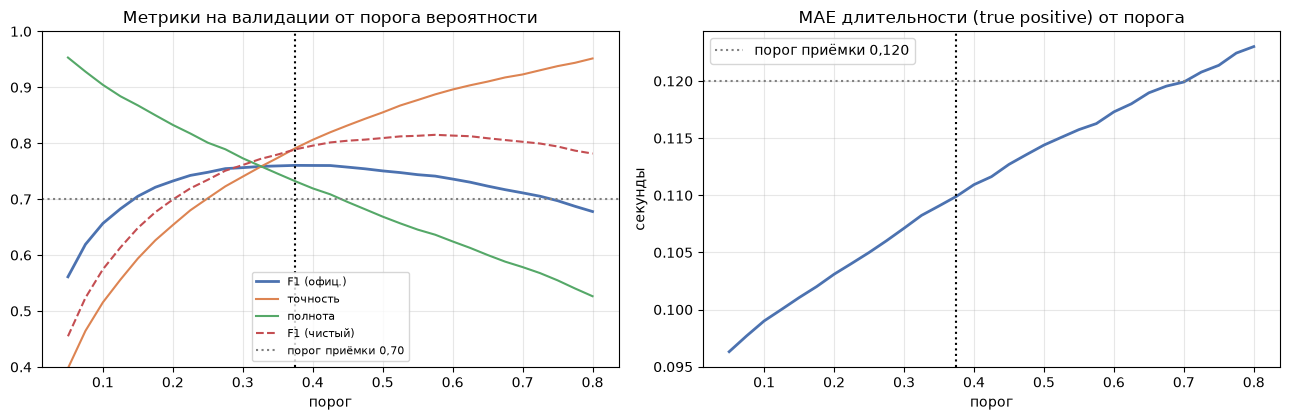

In [ ]:
# Финальный вариант - лучший по официальному F1 на валидации
best_name = variants_table["F1 офиц."].idxmax()
CLF_LABEL, REG_LABEL = variants[best_name]
print("Выбран вариант:", best_name)

model_val, proba_val, dur_val, _ = cache[best_name]
grid = np.arange(0.05, 0.801, 0.025)
mval = val_df.is_last_word.values == 0
curve = []
for t in grid:
    off, cln = report(val_df, proba_val, dur_val, t)
    curve.append({"thr": t, "F1": off["F1"], "P": off["P"], "R": off["R"], "MAE": off["MAE"], "F1 чистый": cln["F1"]})
curve = pd.DataFrame(curve)
THRESHOLD = float(curve.loc[curve.F1.idxmax(), "thr"])
print(f"Порог по максимуму официального F1 на валидации: {THRESHOLD:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(curve.thr, curve.F1, label="F1 (офиц.)", color=BLUE, linewidth=2)
axes[0].plot(curve.thr, curve.P, label="точность", color=ORANGE)
axes[0].plot(curve.thr, curve.R, label="полнота", color=GREEN)
axes[0].plot(curve.thr, curve["F1 чистый"], label="F1 (чистый)", color=RED, linestyle="--")
axes[0].axhline(0.70, color="gray", linestyle=":", label="порог приёмки 0,70")
axes[0].axvline(THRESHOLD, color="black", linestyle=":")
axes[0].set(title="Метрики на валидации от порога вероятности", xlabel="порог", ylim=(0.4, 1.0))
axes[0].legend(fontsize=8)
axes[1].plot(curve.thr, curve.MAE, color=BLUE, linewidth=2)
axes[1].axhline(0.12, color="gray", linestyle=":", label="порог приёмки 0,120")
axes[1].axvline(THRESHOLD, color="black", linestyle=":")
axes[1].set(title="MAE длительности (true positive) от порога", xlabel="порог", ylabel="секунды")
axes[1].legend()
plt.tight_layout()
plt.show()

In [31]:
curve[curve.thr.round(3).isin([0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6])].round(3).set_index("thr")

,F1,P,R,MAE,F1 чистый
thr,,,,,
0.20,0.732,0.654,0.833,0.103,0.699
0.25,0.748,0.702,0.801,0.105,0.735
0.30,0.756,0.740,0.773,0.107,0.761
0.35,0.759,0.774,0.745,0.109,0.780
0.40,0.760,0.806,0.719,0.111,0.796
0.45,0.757,0.832,0.695,0.113,0.804
0.50,0.750,0.855,0.669,0.114,0.809
0.55,0.744,0.877,0.646,0.116,0.813
0.60,0.736,0.896,0.624,0.117,0.814


**Устойчивость.** Размер деревьев и шаг обучения меняют F1 в пределах 0,759–0,761, а MAE - 0,110–0,111: модель не чувствительна к гиперпараметрам.
Кривая F1 по порогу плоская между 0,3 и 0,5 (0,750–0,760, разброс ≈ 1 п.п.), поэтому точный выбор порога (0,375) не критичен. При росте порога
точность растёт (0,74 → 0,86), полнота падает (0,77 → 0,67). MAE длительности медленно растёт (0,107 → 0,114): остаются только самые вероятные паузы,
среди которых больше длинных, а их длительность предсказать труднее всего. F1 на «чистой» разметке растёт вплоть до порога 0,55–0,6 (0,81), так как в ней нет
спорных слов с микропаузами, и повышенная точность не штрафуется потерей полноты.

### 4.8. Финальная модель и замеры на `train` и `test`

Модель переобучается на всём `train` с найденным порогом и сохраняется в `models/pause_model.pkl` - оттуда её загружает
`PausePredictor()`. На `test` она применяется первый и единственный раз.

In [32]:
final = train_model(train_full, CLF_LABEL, REG_LABEL)
final.threshold = THRESHOLD
final.save()
print("Модель сохранена:", pp.MODEL_PATH, f"({pp.MODEL_PATH.stat().st_size / 1e6:.1f} МБ)")

rows = []
preds = {}
for name, frame in [("train", train_full), ("test", test_df)]:
    proba, dur = predict_proba(final, frame)
    preds[name] = (proba, dur)
    off, cln = report(frame, proba, dur, THRESHOLD)
    rows.append({"выборка": name, "протокол": "официальный", **off})
    rows.append({"выборка": name, "протокол": "чистый", **cln})
final_table = pd.DataFrame(rows).set_index(["выборка", "протокол"])
final_table.round(3)

Модель сохранена: D:\python_projects\ITMO\tts_labs_itmo\labs\lab2_pauses\models\pause_model.pkl (1.4 МБ)


F1      P      R    MAE    слов
выборка протокол                                       
train   официальный  0.803  0.827  0.781  0.098  181090
        чистый       0.824  0.774  0.881  0.107  147534
test    официальный  0.754  0.777  0.733  0.108   45127
        чистый       0.778  0.717  0.850  0.115   37206

In [33]:
# Проверка «как у проверяющего»: запуск приложенного скрипта на всех данных
import subprocess, sys
res = subprocess.run([sys.executable, "pause_predictor.py"], capture_output=True, text=True, encoding="utf-8")
print(res.stdout)
assert res.returncode == 0, res.stderr[-2000:]

Calculate metrics, traning fold; Exclude last tokens in every sentence!
PRC: 0.8268933104438128, REC: 0.7808754351928137, F1: 0.8032258064516129; MAE: 0.0977417716309047;

Calculate metrics, testing fold; Exclude last tokens in every sentence!
PRC: 0.7772722102149926, REC: 0.7329972108989488, F1: 0.7544857284823056; MAE: 0.10819063500950599;



**Результат.** На `test` в официальном протоколе **F1 = 0,754** (точность 0,78, полнота 0,73) и **MAE = 0,108 с**; на «чистом» -
F1 = 0,778, MAE = 0,115. Оба значения выполняют обновлённые пороги (F1 ≥ 0,70, MAE < 0,120), причём F1 на 5 п.п. выше порога.
Разрыв с `train` (F1 0,803, MAE 0,098) умеренный: модель не переобучена. Запуск приложенного скрипта `pause_predictor.py` воспроизводит те же цифры.

### 4.9. Почему ошибки такие большие

Откуда берутся высокие абсолютные ошибки. Разберём их на `test` у финальной модели.

In [34]:
proba_t, dur_t = preds["test"]
T = test_df.copy()
T["proba"] = proba_t
T["h"] = (proba_t >= THRESHOLD).astype(int)
T["d_hat"] = np.where(T.h == 1, np.maximum(dur_t, pp.MIN_DURATION), 0.0)
T["punct"] = rule_cls(T)
T = T[T.is_last_word == 0].reset_index(drop=True)
T["tp"] = (T.is_pause_after == 1) & (T.h == 1)

def by_class(g):
    tp, fp, fn = (g.tp).sum(), ((g.is_pause_after == 0) & (g.h == 1)).sum(), ((g.is_pause_after == 1) & (g.h == 0)).sum()
    return pd.Series({"слов": len(g), "доля пауз в разметке": g.is_pause_after.mean(), "доля предсказанных": g.h.mean(),
                      "точность": tp / max(tp + fp, 1), "полнота": tp / max(tp + fn, 1), "ложные": fp, "пропущенные": fn})

cls_order = ["end", "semi", "comma", "dash", "none"]
breakdown = T.groupby("punct").apply(by_class, include_groups=False).reindex([c for c in cls_order if c in set(T.punct)])
breakdown.round(3)

,слов,доля пауз в разметке,доля предсказанных,точность,полнота,ложные,пропущенные
punct,,,,,,,
end,4069.0,0.947,0.986,0.956,0.995,178.0,20.0
comma,4102.0,0.530,0.697,0.658,0.866,979.0,292.0
dash,765.0,0.659,0.800,0.747,0.907,155.0,47.0
none,36191.0,0.077,0.036,0.506,0.237,646.0,2130.0


In [35]:
# Из чего складывается MAE: TP-слова по истинной длительности паузы
tp = T[T.tp].copy()
tp["err"] = (tp.pause_duration - tp.d_hat).abs()
tp["bucket"] = pd.cut(tp.pause_duration, [0, 0.055, 0.15, 0.3, 5], labels=["30–50 мс", "60–150 мс", "160–300 мс", "> 300 мс"])
mae_table = tp.groupby("bucket", observed=True).agg(слов=("err", "size"), средняя_истинная_пауза=("pause_duration", "mean"),
                                                    средняя_предсказанная=("d_hat", "mean"), MAE=("err", "mean"))
mae_table.loc["все"] = [len(tp), tp.pause_duration.mean(), tp.d_hat.mean(), tp.err.mean()]

const_mae = (tp.pause_duration - tp.pause_duration.median()).abs().mean()
cls_med_mae = (tp.pause_duration - tp.punct.map(medians)).abs().mean()
print(f"MAE, если всегда предсказывать одну константу (медиана): {const_mae:.3f} с")
print(f"MAE, если предсказывать медиану по классу знака:         {cls_med_mae:.3f} с")
print(f"MAE модели:                                               {tp.err.mean():.3f} с")
print(f"Вклад микропауз (30–50 мс) в сумму ошибок: {tp[tp.pause_duration < 0.055].err.sum() / tp.err.sum():.1%} "
      f"при доле таких пауз среди TP {(tp.pause_duration < 0.055).mean():.1%}")
mae_table.round(3)

MAE, если всегда предсказывать одну константу (медиана): 0.121 с
MAE, если предсказывать медиану по классу знака:         0.118 с
MAE модели:                                               0.108 с
Вклад микропауз (30–50 мс) в сумму ошибок: 17.5% при доле таких пауз среди TP 23.9%


,слов,средняя_истинная_пауза,средняя_предсказанная,MAE
bucket,,,,
30–50 мс,1635.0,0.035,0.114,0.079
60–150 мс,1972.0,0.099,0.142,0.060
160–300 мс,1725.0,0.219,0.167,0.075
> 300 мс,1501.0,0.431,0.191,0.241
все,6833.0,0.187,0.152,0.108


Слов с вероятностью паузы между 0,2 и 0,7: 13.7%; на них приходится 52.9% всех ошибок классификации


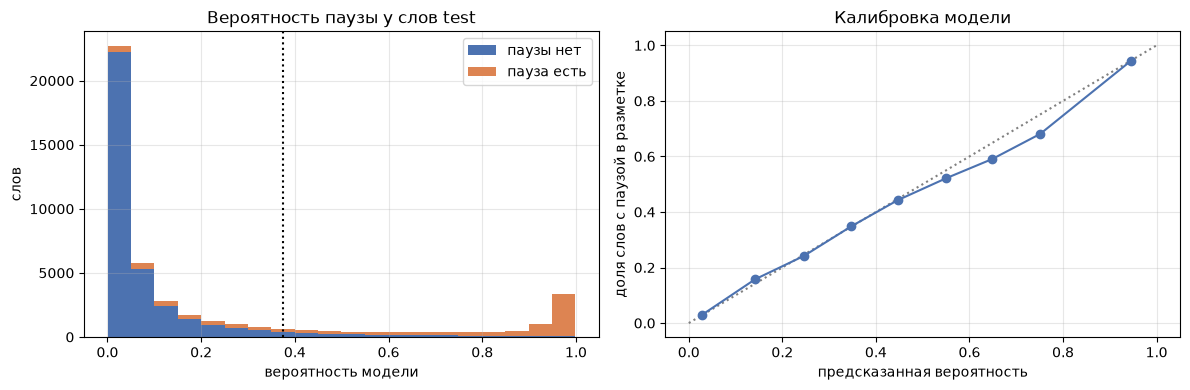

,слов,доля_пауз_в_разметке,"доля слов, %"
p_bin,,,
"(-0.001, 0.1]",28446,0.030,63.0
"(0.1, 0.2]",4535,0.158,10.0
"(0.2, 0.3]",2239,0.242,5.0
"(0.3, 0.4]",1438,0.348,3.2
"(0.4, 0.5]",965,0.442,2.1
"(0.5, 0.6]",799,0.522,1.8
"(0.6, 0.7]",760,0.591,1.7
"(0.7, 0.8]",759,0.681,1.7
"(0.8, 1.0]",5186,0.945,11.5


In [36]:
# Калибровка: как часто пауза есть на самом деле при заданной вероятности модели
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
T["p_bin"] = pd.cut(T.proba, bins, include_lowest=True)
calib = T.groupby("p_bin", observed=True).agg(слов=("proba", "size"), доля_пауз_в_разметке=("is_pause_after", "mean"))
calib["доля слов, %"] = (calib["слов"] / len(T) * 100).round(1)

err = (T.h != T.is_pause_after)
uncertain = T.proba.between(0.2, 0.7)
print(f"Слов с вероятностью паузы между 0,2 и 0,7: {uncertain.mean():.1%}; на них приходится {err[uncertain].sum() / err.sum():.1%} всех ошибок классификации")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([T[T.is_pause_after == 0].proba, T[T.is_pause_after == 1].proba], bins=20, stacked=True,
             label=["паузы нет", "пауза есть"], color=[BLUE, ORANGE])
axes[0].axvline(THRESHOLD, color="black", linestyle=":")
axes[0].set(title="Вероятность паузы у слов test", xlabel="вероятность модели", ylabel="слов")
axes[0].legend()
mid_ = calib.reset_index()
axes[1].plot([0, 1], [0, 1], color="gray", linestyle=":")
axes[1].plot(T.groupby("p_bin", observed=True).proba.mean(), calib.доля_пауз_в_разметке, marker="o", color=BLUE)
axes[1].set(title="Калибровка модели", xlabel="предсказанная вероятность", ylabel="доля слов с паузой в разметке")
plt.tight_layout()
plt.show()
calib.round(3)

#### Согласие диктора с самим собой

В корпусе есть фразы, которые диктор прочитал дважды. Если он сам не повторяет паузы в одном и том же тексте,
то предсказатель не может «точно воспроизвести диктора» даже в принципе. Сравним две записи одной фразы (пары из ≥ 5 слов,
одинаковый текст).

In [37]:
d5 = data[data.is_last_word == 0]
texts = data.groupby("id").label.apply(lambda s: " ".join(s.astype(str)))
nwords = data.groupby("id").size()
texts = texts[nwords >= 5]
dup_groups = texts[texts.duplicated(keep=False)].groupby(texts[texts.duplicated(keep=False)]).apply(lambda s: list(s.index))
by_id = {k: g for k, g in d5.groupby("id")}

pa, pb, da, db = [], [], [], []
for ids in dup_groups:
    for i in range(len(ids) - 1):
        a, b = by_id.get(ids[i]), by_id.get(ids[i + 1])
        if a is None or b is None or len(a) != len(b):
            continue
        pa.append(a.is_pause_after.values); pb.append(b.is_pause_after.values)
        da.append(a.pause_duration.values); db.append(b.pause_duration.values)
pa, pb, da, db = map(np.concatenate, (pa, pb, da, db))
both = (pa == 1) & (pb == 1)
print(f"Пар записей: {len(dup_groups)} текстов, слов: {len(pa)}")
print(f"F1 между двумя чтениями одной фразы: {f1_score(pa, pb):.3f}")
print(f"MAE длительности между чтениями (пауза есть в обоих, {both.sum()} слов): {np.abs(da[both] - db[both]).mean():.3f} с")

Пар записей: 198 текстов, слов: 2314
F1 между двумя чтениями одной фразы: 0.650
MAE длительности между чтениями (пауза есть в обоих, 282 слов): 0.163 с


In [38]:
# Примеры ошибок на test: контекст «предыдущее слово [слово с паузой] следующее слово»
ex = test_df.copy()
ex["prev_tok"] = ex.groupby("id").label_raw.shift(1).fillna("")
ex["next_tok"] = ex.groupby("id").label_raw.shift(-1).fillna("")
ex["proba"], ex["h"] = preds["test"][0], (preds["test"][0] >= THRESHOLD).astype(int)
ex = ex[ex.is_last_word == 0]
ex["punct"] = rule_cls(ex)

def show(df, n=8, seed=3):
    d = df.sample(min(n, len(df)), random_state=seed)
    return pd.DataFrame({"контекст": d.prev_tok + " [" + d.label_raw + "] " + d.next_tok,
                         "пауза в разметке, с": d.pause_duration.round(2), "вероятность модели": d.proba.round(2)}).reset_index(drop=True)

print("Пропущенные паузы ≥ 150 мс на словах без знака препинания (модель уверена, что паузы нет):")
display(show(ex[(ex.punct == "none") & (ex.is_pause_after == 1) & (ex.pause_duration >= 0.15) & (ex.h == 0)]))
print("Лишние паузы: запятая есть, в разметке паузы нет, модель уверена (p > 0,8):")
display(show(ex[(ex.punct == "comma") & (ex.is_pause_after == 0) & (ex.proba > 0.8)]))

Пропущенные паузы ≥ 150 мс на словах без знака препинания (модель уверена, что паузы нет):


,контекст,"пауза в разметке, с",вероятность модели
0,"литературе, — [Карл] Проффер.",0.17,0.25
1,Лемкуса. [Выслушал] какую-то,0.18,0.03
2,Черное [лицо] и,0.15,0.22
3,выглядеть [подонком] в,0.17,0.34
4,почему- [то] в,0.17,0.05
5,"Или, [скажем""] Петрову",0.19,0.32
6,говна. [Проходит] лет,1.67,0.02
7,Поздравляю! [Спектакль] отличный!,0.22,0.16


Лишние паузы: запятая есть, в разметке паузы нет, модель уверена (p > 0,8):


,контекст,"пауза в разметке, с",вероятность модели
0,"был"" [розовым"",] левым.",0.0,0.80
1,"вот [растолковать,] что",0.0,0.80
2,"о [том,] чего",0.0,0.84
3,"рулон [полиэтилена,] считается",0.0,0.82
4,"таким [образом,] любовь",0.0,0.95
5,"себя, [Красноперов,] горюй.",0.0,0.83
6,"про [Ахмадулину,] я",0.0,0.89
7,"узнавал [Пушкина,] тем",0.0,0.87


**Почему ошибки такие большие - сводка.**

1. **Паузы без знаков препинания почти непредсказуемы.** 86 % пропущенных пауз приходится на слова без знака препинания
   (2130 из 2489 на `test`): модель находит лишь 24 % таких пауз. Это границы синтагм, которые запятой не отмечены:
   в примерах выше диктор паузит после глагола или причастного оборота перед новой группой («нужно выбирать / между», «я подумал / вот»,
   «старик, достигший / всех»), но модель с вероятностью 0,04–0,3 считает, что слова читаются слитно. Правила здесь нет, есть лишь склонность.
2. **Запятая - это «может быть».** В разметке паузу после запятой диктор делает в 53 % случаев, после тире - в 66 %. Модель
   ставит её чаще (70 % и 80 %) и получает 979 лишних пауз на запятых: там, где диктор паузу не сделал, текст выглядит точно так же
   (в примерах выше - вводное слово «Кстати,», короткий оборот «не покорностью, а», перечисление «довоенные пластинки, и»: такие
   запятые диктор проговаривает слитно).
3. **Основная масса ошибок лежит в «серой зоне».** Слова с вероятностью паузы между 0,2 и 0,7 составляют 14 % выборки, а ошибок на них - 53 %.
   Калибровка модели близка к диагонали (у слов с p ≈ 0,4–0,5 пауза есть в 44 % случаев) - модель честно оценивает
   неопределённость, то есть ошибки не исправить подбором признаков: они определяются самим явлением.
4. **Диктор непоследователен сам с собой.** На 198 текстах, которые он прочёл дважды, две записи совпадают по местам пауз лишь на F1 = 0,65,
   а длительности пауз, присутствующих в обеих записях, различаются в среднем на 0,163 с. Наш предиктор (F1 0,75; MAE 0,108) на чужих
   фразах попадает в разметку точнее, чем диктор повторяет собственное чтение (выборка мала, 2314 слов, и повтор мог быть
   перезаписью неудачного дубля, поэтому это оценка порядка величины, а не строгий предел).
5. **Длительность почти не выводится из текста.** Константа-медиана даёт MAE 0,121, медиана по классу знака - 0,118, модель - 0,108: текст объясняет
   лишь малую часть разброса. Регрессор с функцией потерь MAE выдаёт условную медиану, поэтому длинные паузы недооценены (> 300 мс: истинная
   в среднем 0,43 с, предсказанная 0,19 с, MAE 0,24 с) - они образуют «тяжёлый хвост», который по тексту не угадать.
6. **Разметка сама вносит ошибку.** 24 % совпавших пауз - микропаузы 30–50 мс (истинные 35 мс, предсказанные в среднем 114 мс), они дают 17 % всей
   ошибки длительности; сетка MFA 10 мс и артефакты выравнивания (раздел 2) не позволяют ожидать ошибки ниже нескольких десятков мс.

Итог: для синтеза речи цель - не воспроизвести конкретное чтение, а поставить **допустимые** паузы; для этой цели предсказатель,
который знает, где пауза почти обязательна (конец предложения - 99,5 % полноты, запятые - 87 %), и выдаёт типичную длительность, достаточен.

### 4.10. Примеры работы предиктора

Паузы отмечены значком `⟦мс⟧` после слова: в разметке диктора (MFA) и в предсказании модели. Фразы из `test` выбраны **случайно**
(фиксированное зерно), без отбора удачных. Последнее слово не учитывается, как и в метриках.

In [ ]:
def render(tokens, is_pause, durations):
    out = []
    for tok, p_, d_ in zip(tokens, is_pause, durations):
        out.append(tok + (f" [{int(round(d_ * 1000))}]" if p_ else ""))
    return " ".join(out)

ids_te, sents_te, _ = pp.sentences_from_frame(test_df)
by_id_te = {k: g for k, g in test_df.groupby("id")}
rng = np.random.default_rng(11)
cand = [k for k in range(len(ids_te)) if 8 <= len(sents_te[k]) <= 16]
for k in rng.choice(cand, 6, replace=False):
    g = by_id_te[ids_te[k]]
    true_p = g.is_pause_after.values.copy(); true_d = g.pause_duration.values.copy()
    true_p[-1], true_d[-1] = 0, 0.0                      # последнее слово не оценивается
    hat_p, hat_d = final.predict(sents_te[k])
    hat_p[-1], hat_d[-1] = 0, 0.0
    m_ = np.arange(len(true_p)) < len(true_p) - 1
    tp_ = int(((true_p == 1) & (hat_p == 1) & m_).sum())
    print(ids_te[k], f"(совпало пауз: {tp_} из {int((true_p[m_]).sum())} в разметке, модель поставила {int(hat_p[m_].sum())})")
    print("  диктор:", render(sents_te[k], true_p, true_d))
    print("  модель:", render(sents_te[k], hat_p, hat_d))
    print()

012715_RUSLAN (совпало пауз: 1 из 1 в разметке, модель поставила 2)
  диктор: Пока моя группа осматривала домик няни, ⟦80⟧ Виктория Альбертовна шептала
  модель: Пока моя группа осматривала домик няни, ⟦101⟧ Виктория Альбертовна ⟦39⟧ шептала

017945_RUSLAN (совпало пауз: 2 из 3 в разметке, модель поставила 3)
  диктор: Все их знакомые были уверены, что это— следствие ⟦50⟧ антисемитизма. ⟦210⟧ Пожалуй, ⟦30⟧ так оно и было.
  модель: Все их знакомые были уверены, ⟦95⟧ что это— следствие антисемитизма. ⟦160⟧ Пожалуй, ⟦87⟧ так оно и было.

014530_RUSLAN (совпало пауз: 2 из 2 в разметке, модель поставила 2)
  диктор: Тася перебила меня— ⟦160⟧ Я хотела бы поехать с вами. — ⟦280⟧ Вот и прекрасно.
  модель: Тася перебила меня— ⟦144⟧ Я хотела бы поехать с вами. — ⟦202⟧ Вот и прекрасно.

006575_RUSLAN (совпало пауз: 2 из 3 в разметке, модель поставила 2)
  диктор: Из-за поворота, ⟦200⟧ качнувшись, выехал ⟦30⟧ наполненный светом трамвай. ⟦320⟧ Лида опустилась на деревянную скамью.
  модель: Из-за

Видно типичное поведение модели: надёжные паузы после знаков препинания на границах предложений и запятых она ставит, а «лишние» 30–50 мс и паузы внутри
синтагм, которые диктор сделал по своему усмотрению, угадываются хуже (раздел 4.9). Длительность предсказывается «типичная» для места, поэтому реальные
значения вроде 330 мс модель склонна занижать.

#### Вход для акустической модели (лабораторные №4–5)

`predict_durations` возвращает токены с вставленными `<SIL>` и длительностями: секунды для `<SIL>` и `-1` для слов (их длительность определит акустическая модель).

In [40]:
k = int(rng.choice(cand))
tokens_sil, durs_sil = final.predict_durations(sents_te[k])
pd.DataFrame({"токен": tokens_sil, "длительность, с": np.round(durs_sil, 2)}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
токен,"""Соединенные",Штаты,"Армении…""",<SIL>,Окружающие,любят,не,"честных,",<SIL>,а,добрых.,<SIL>,Не,"смелых,",<SIL>,а,чутких.
"длительность, с",-1.0,-1.0,-1.0,0.21,-1.0,-1.0,-1.0,-1.0,0.07,-1.0,-1.0,0.15,-1.0,-1.0,0.06,-1.0,-1.0


#### Новый текст

Предложения, которых нет в корпусе: сначала токенизатор (раздел 5), затем предиктор.

In [ ]:
new_texts = [
    "Вчера мы с друзьями ходили в кино, а потом долго гуляли по набережной и обсуждали фильм.",
    "Если завтра будет дождь, мы останемся дома, и я наконец допишу письмо, которое давно обещал.",
    "- Ты придёшь? - спросила она. - Обязательно, - ответил он, и дверь тихо закрылась.",
    "Когда в город пришла зима, улицы опустели, и только редкие прохожие торопились домой.",
]
for t_ in new_texts:
    toks_, is_, dur_ = final.predict_text(t_)
    print(render(toks_, np.r_[is_[:-1], 0], np.r_[dur_[:-1], 0.0]))
    print()

Вчера мы с друзьями ходили в кино, ⟦170⟧ а потом долго гуляли по набережной ⟦100⟧ и обсуждали фильм.

Если завтра будет дождь, ⟦109⟧ мы останемся дома, ⟦220⟧ и я наконец допишу письмо, ⟦122⟧ которое давно обещал.

— Ты придёшь? — спросила она. — ⟦182⟧ Обязательно, — ответил он, ⟦129⟧ и дверь тихо закрылась.

Когда в город пришла зима, ⟦91⟧ улицы опустели, ⟦182⟧ и только редкие прохожие торопились домой.



На новых предложениях предиктор ведёт себя осмысленно: ставит паузы после запятых перед союзами («…в кино, ⟦170⟧ а потом…», «…дождь, ⟦109⟧ мы останемся…»)
и самую длинную паузу - на границе крупных синтагм (220 мс перед «и я наконец допишу…»). Заметный промах - в диалоге: после «Ты придёшь? -» пауза не поставлена,
хотя после слов со знаком конца предложения диктор паузит в 94,5 % случаев (раздел 2.2). Значит, токен со знаком конца предложения и тире модель обрабатывает хуже, чем обычный.

## 5. Дополнительное задание: токенизатор

Предиктор принимает предложение как последовательность токенов в формате `label_raw`: **слово вместе со знаками, которые идут после него**
(`Хватает, -`, `согласился`, `он.`). В обучающей таблице такие токены получены из слов MFA. В реальной системе синтеза на входе
будет просто текст, поэтому нужен токенизатор, который из строки получает те же токены. Наивный вариант - делить по пробелу.
Проверим его и сравним с токенизацией MFA, которую возьмём за эталон (колонка `label_raw`).

In [42]:
def fix_text(t):
    # те же замены, что делает prepare_training_data.py перед сопоставлением с разметкой
    return t.replace("‐", "-").replace("‑", "-").replace("’", "'")

ref_ids, ref_sents, _ = pp.sentences_from_frame(pause_df)
ref_tokens = dict(zip(ref_ids, ref_sents))
nrm_text = {i: fix_text(t) for i, t in zip(ruslan.id, ruslan.nrm) if i in ref_tokens}
raw_text = dict(zip(ruslan.id, ruslan.raw.astype(str)))

tokenizers = {"по пробелу (split)": pp.split_on_whitespace, "tokenize_text": pp.tokenize_text}
rows = {}
for name, fn in tokenizers.items():
    toks = {i: fn(t) for i, t in nrm_text.items()}
    rows[name] = {
        "фраз, токены совпали полностью, %": np.mean([toks[i] == ref_tokens[i] for i in toks]) * 100,
        "фраз с тем же числом токенов, %": np.mean([len(toks[i]) == len(ref_tokens[i]) for i in toks]) * 100,
        "токенов в эталоне": sum(len(v) for v in ref_tokens.values()),
        "токенов у токенизатора": sum(len(v) for v in toks.values()),
    }
pd.DataFrame(rows).T.round(1)

,"фраз, токены совпали полностью, %","фраз с тем же числом токенов, %",токенов в эталоне,токенов у токенизатора
по пробелу (split),69.3,73.6,247787.0,257796.0
tokenize_text,98.5,98.5,247787.0,247460.0


Деление по пробелу полностью совпало с MFA менее чем в 70 % фраз. Посмотрим, в чём причины.

In [43]:
toks_split = {i: pp.split_on_whitespace(t) for i, t in nrm_text.items()}
has_hyphen_split = {i: any(pp.split_token(x)[1].endswith("-") for x in ref_tokens[i]) for i in ref_tokens}
has_lone_punct = {i: any(not re.search(r"\w", x) for x in toks_split[i]) for i in toks_split}
# знак прилеплен к следующему слову (открывающая кавычка, скобка), а в эталоне он принадлежит предыдущему
has_left_punct = {i: any(re.match(r"\W", x) and re.search(r"\w", x) for x in toks_split[i][1:]) for i in toks_split}

def reason(i):
    # причины перечислены по убыванию приоритета: фраза попадает в первую подходящую категорию
    if toks_split[i] == ref_tokens[i]:
        return "совпало"
    if has_lone_punct[i]:
        return "знак стоит отдельным токеном (тире, кавычка)"
    if has_left_punct[i]:
        return "знак слева от слова (открывающая кавычка, скобка)"
    if has_hyphen_split[i]:
        return "MFA разрезал дефисное слово"
    return "другое"

reasons = pd.Series({i: reason(i) for i in toks_split}).value_counts()
pd.DataFrame({"фраз": reasons, "доля, %": (reasons / reasons.sum() * 100).round(1)})

,фраз,"доля, %"
совпало,14955,69.3
"знак стоит отдельным токеном (тире, кавычка)",5392,25.0
"знак слева от слова (открывающая кавычка, скобка)",914,4.2
MFA разрезал дефисное слово,307,1.4
другое,2,0.0


In [44]:
examples = [i for i in toks_split if toks_split[i] != ref_tokens[i]]
rng = np.random.default_rng(5)
picked = [examples[k] for k in rng.choice(len(examples), 4, replace=False)]
# отдельно фраза с тире и фраза с «разрезанным» дефисом
picked += [i for i in examples if has_hyphen_split[i] and not has_lone_punct[i]][:1]
for i in picked:
    print(nrm_text[i])
    print("  split        :", toks_split[i])
    print("  tokenize_text:", pp.tokenize_text(nrm_text[i]))
    print("  MFA (эталон) :", ref_tokens[i])
    print()

Оркестр заиграл "Сентябрь в Париже". Анук Эме протянула свою фотографию с надписью
  split        : ['Оркестр', 'заиграл', '"Сентябрь', 'в', 'Париже".', 'Анук', 'Эме', 'протянула', 'свою', 'фотографию', 'с', 'надписью']
  tokenize_text: ['Оркестр', 'заиграл"', 'Сентябрь', 'в', 'Париже".', 'Анук', 'Эме', 'протянула', 'свою', 'фотографию', 'с', 'надписью']
  MFA (эталон) : ['Оркестр', 'заиграл"', 'Сентябрь', 'в', 'Париже".', 'Анук', 'Эме', 'протянула', 'свою', 'фотографию', 'с', 'надписью']

Неожиданно он что-то выкрикнул противным хриплым голосом.
  split        : ['Неожиданно', 'он', 'что-то', 'выкрикнул', 'противным', 'хриплым', 'голосом.']
  tokenize_text: ['Неожиданно', 'он', 'что-то', 'выкрикнул', 'противным', 'хриплым', 'голосом.']
  MFA (эталон) : ['Неожиданно', 'он', 'что-', 'то', 'выкрикнул', 'противным', 'хриплым', 'голосом.']

Среди них попадались, конечно, милые и вежливые люди, но на всякий случай изначально я мобилизовывал все уменьшительные суффиксы, потому что эти люди м

**Почему деление по пробелу ошибается.**

- **Знаки, стоящие отдельно** (тире между пробелами, одиночная кавычка, точка в начале) по пробелу становятся самостоятельными токенами,у которых нет слова: предиктор увидел бы «слово» `-`, а следующее слово сдвинулось бы на позицию. В эталоне такой знак приклеен к предыдущему слову (`Хватает, -`), а ведущий знак - к первому (`. Глубокой`).
- **Открывающие кавычки и скобки.** По пробелу они остаются у следующего слова (`"Сентябрь`), а в эталоне *всё, что лежит между двумя словами, принадлежит предыдущему слову* (`заиграл"`, `Сентябрь`). Для предиктора это важно: признаки пунктуации берутся из «хвоста» токена, и при делении по пробелу кавычка или скобка попадает не к тому слову.
- **Дефисные слова.** Их судьба в эталоне интереснее (см. ниже).

In [45]:
# Как MFA обошёлся с дефисными словами в зависимости от символа дефиса в СЫРОМ тексте
tab = {}
for i, t in nrm_text.items():
    cores = {pp.split_token(x)[1] for x in ref_tokens[i]}
    raw = raw_text[i]
    for m in re.finditer(r"(?<![\w-])(\w+(?:-\w+)+)(?![\w-])", t):
        w = m.group(0)
        a, b = w.split("-", 1)
        mr = re.search(re.escape(a) + r"([-‐‑‒])" + re.escape(b.split("-")[0]), raw)
        ch = {"-": "обычный дефис «-» (U+002D)", "‑": "неразрывный дефис «‑» (U+2011)"}.get(mr.group(1) if mr else "?", "другой")
        k = (ch, "оставлен целым" if w in cores else "разрезан на части")
        tab[k] = tab.get(k, 0) + 1
pd.Series(tab).unstack().fillna(0).astype(int)

,оставлен целым,разрезан на части
неразрывный дефис «‑» (U+2011),2122,0
обычный дефис «-» (U+002D),3,325


**Причина расхождения с MFA - особенность входных данных, а не языка.** Разметка построена по *сырому* тексту, а в нём дефисные слова (`что‑то`, `как‑то`) в подавляющем большинстве набраны неразрывным дефисом `‑` (U+2011), которого MFA не считает разделителем, и он оставляет слово целым.Те немногие слова, где стоит обычный дефис `-`, MFA режет на две части (`этом-` + `то`). После нормализации лабы 1 оба дефиса одинаковы, и отличить эти случаи по нормализованному тексту уже нельзя. Поэтому токенизатор **не режет дефисные слова**: «что-то» - это одно слово, и так оно совпадает с эталоном в подавляющем большинстве случаев.

**Алгоритм `tokenize_text`** (`pause_predictor.py`): слово - это последовательность букв/цифр (вместе со знаком ударения), внутри которой допустимы дефис и апостроф;
токен = слово + вся пунктуация до следующего слова (без пробелов по краям); пунктуация в начале текста приклеивается к первому слову; строки без слов дают пустой список.

In [ ]:
cases = ["Хватает, - согласился он.", "- Привет, - сказал он. - Как дела?", "«Что-то не так», - подумал д'Артаньян.",
         ". Глубокой ночью...", "Я родился в Санкт-Петербурге   в  1990-м году.", "", "!!!"]
for c in cases:
    print(repr(c), "->", pp.tokenize_text(c))

'Хватает, — согласился он.' -> ['Хватает, —', 'согласился', 'он.']
'— Привет, — сказал он. — Как дела?' -> ['— Привет, —', 'сказал', 'он. —', 'Как', 'дела?']
"«Что-то не так», — подумал д'Артаньян." -> ['«Что-то', 'не', 'так», —', 'подумал', "д'Артаньян."]
'. Глубокой ночью...' -> ['. Глубокой', 'ночью...']
'Именно так поставив ударение — «ебну́лся».' -> ['Именно', 'так', 'поставив', 'ударение— «', 'ебну́лся».']
'Я родился в Санкт-Петербурге   в  1990-м году.' -> ['Я', 'родился', 'в', 'Санкт-Петербурге', 'в', '1990-м', 'году.']
'' -> []
'!!!' -> []


In [47]:
# Остаточные расхождения токенизатора с эталоном
toks_new = {i: pp.tokenize_text(t) for i, t in nrm_text.items()}
diff = [i for i in toks_new if toks_new[i] != ref_tokens[i]]
explained = sum(has_hyphen_split[i] for i in diff)
print(f"Не совпало с эталоном: {len(diff)} из {len(toks_new)} фраз ({len(diff) / len(toks_new):.2%}); из них разрезанный MFA дефис: {explained}")
n_hy = sum(1 for v in ref_tokens.values() for x in v if pp.split_token(x)[1].endswith("-"))
pause_after_hy = pause_df[pause_df.label_raw.astype(str).map(lambda x: pp.split_token(x)[1].endswith("-"))]
print(f"В эталоне токенов с «оторванной» частью дефисного слова: {n_hy}; после них паузу MFA поставил в {pause_after_hy.is_pause_after.sum()} случаях")

Не совпало с эталоном: 316 из 21570 фраз (1.46%); из них разрезанный MFA дефис: 316

В эталоне токенов с «оторванной» частью дефисного слова: 363; после них паузу MFA поставил в 35 случаях


#### Влияние на предиктор пауз

Сравним на `test` предсказания модели при токенизации по пробелу и при `tokenize_text`. Берём фразы, где токенизатор совпал с эталоном, а число токенов со словами при делении по пробелу
равно числу слов эталона (чтобы решения можно было сопоставить по словам). При токенизации по пробелу отдельные знаки остаются самостоятельными токенами
и участвуют в признаках (сдвигают позиции, становятся «следующим словом»), но оцениваются только решения для токенов со словами.

In [48]:
ids_t, sents_t, row_sent = pp.sentences_from_frame(test_df)
good, toks0, masks = [], [], []
for k, uid in enumerate(ids_t):
    t0 = pp.split_on_whitespace(nrm_text[uid]) if uid in nrm_text else []
    m0 = np.array([bool(re.search(r"\w", t)) for t in t0], dtype=bool)
    if uid in nrm_text and m0.sum() == len(sents_t[k]) and pp.tokenize_text(nrm_text[uid]) == sents_t[k]:
        good.append(k); toks0.append(t0); masks.append(m0)
print(f"Фраз test для сравнения: {len(good)} из {len(ids_t)}")

is0, d0 = final.predict_many(toks0)
keep = np.concatenate(masks)
is0, d0 = is0[keep], d0[keep]
is1, d1 = final.predict_many([sents_t[k] for k in good])
frame = test_df[np.isin(row_sent, good)].reset_index(drop=True)
assert len(frame) == len(is0) == len(is1)

rows = []
for name, (h, d) in {"по пробелу (split)": (is0, d0), "tokenize_text": (is1, d1)}.items():
    off, cln = score(frame, h, d, "official"), score(frame, h, d, "clean")
    rows.append({"токенизатор": name, "F1 офиц.": off["F1"], "MAE офиц.": off["MAE"], "F1 чистый": cln["F1"], "MAE чистый": cln["MAE"]})
m_ = (frame.is_last_word == 0).values
print(f"Решение о паузе отличается у {np.mean(is0[m_] != is1[m_]):.1%} слов")
lone = [i for i, k in enumerate(good) if any(not mk for mk in masks[i])]
print(f"Фраз с отдельно стоящими знаками среди них: {len(lone)} из {len(good)}")
pd.DataFrame(rows).set_index("токенизатор").round(3)

Фраз test для сравнения: 4250 из 4317


Решение о паузе отличается у 2.2% слов
Фраз с отдельно стоящими знаками среди них: 1083 из 4250


,F1 офиц.,MAE офиц.,F1 чистый,MAE чистый
токенизатор,,,,
по пробелу (split),0.726,0.108,0.746,0.116
tokenize_text,0.756,0.108,0.779,0.115


In [ ]:
# Сквозной пример: текст -> токены -> паузы
text = "Хватает, - согласился он и тихо добавил: всё это только начало."
tokens, is_p, dur = final.predict_text(text)
pd.DataFrame({"токен": tokens, "пауза после": is_p, "длительность, с": dur.round(2)})

,токен,пауза после,"длительность, с"
0,"Хватает, —",0,0.00
1,согласился,0,0.00
2,он,0,0.00
3,и,0,0.00
4,тихо,0,0.00
5,добавил:,1,0.13
6,всё,0,0.00
7,это,0,0.00
8,только,0,0.00
9,начало.,0,0.00


**Итоги по токенизатору.**

- Деление по пробелу воспроизводит токены MFA лишь в **69 %** фраз и порождает ~10 тыс. лишних токенов (отдельные тире и кавычки); `tokenize_text` - в **98,5 %**.
  Оставшиеся 1,5 % (316 фраз) - целиком артефакт разметки: слова с обычным дефисом MFA разрезал на две части (`этом-` + `то`), а мы намеренно оставляем их одним словом.
  После «оторванных» частей паузы в разметке почти нет (35 из 363), так что расхождение на качество обучения практически не влияет.
- На качество предиктора токенизация влияет заметно: на `test` F1 падает с 0,756 до 0,726 (чистый протокол: 0,779 → 0,746), если подавать текст, разбитый по пробелу, хотя решение о паузе меняется лишь у 2 % слов (отдельные знаки есть в каждой четвёртой фразе: 1083 из 4250). MAE не меняется (0,108).
- Токенизатор встроен в предиктор: `PausePredictor.predict_text(text)` принимает строку и возвращает токены, места пауз и длительности.

## 6. Дополнительное задание: улучшение разметки

### 6.1. Что не так с базовой разметкой v2 и что делаем

По результатам разведки у базовой разметки несколько слабых мест:

- она построена по **сырому** тексту, а не по нормализованному из лабы 1: скобки остались в аудио-разметке, но исчезли из текста (потеряно 284 фразы);
- в 9–10 % фраз встречаются нераспознанные слова (`spn`): словарь MFA не знает фамилии, имена и варианты написания без «ё»;
- слова с обычным дефисом MFA разрезал на части, слова с неразрывным дефисом - нет (раздел 5), то есть токенизация зависела от типографики исходника.

Решение - **перезапустить выравнивание по нормализованному тексту** и дополнить словарь. Воспроизводится скриптом `realign_mfa.py` (MFA 3.4.1 в Docker, модели `russian_mfa` 3.1.0):

1. `corpus` - каталог с жёсткими ссылками на WAV и файлами `.txt` с нормализованным текстом (знак ударения убран: MFA его не знает);
2. `oov` - слова корпуса, которых нет в словаре MFA;
3. `g2p` - произношения для них из G2P-модели, расширенный словарь `russian_mfa_ruslan.dict`;
4. `align` - `mfa align` с профилем одного диктора (`--single_speaker`) и увеличенным лучом (`--beam 100 --retry_beam 400`); 13 минут на весь корпус;
5. `table` - таблица слов в формате лабы (плюс `spn` и `start`): токены те же, что делает `tokenize_text`, а разрезанные MFA части дефисных слов склеиваются обратно.

Результат: `data/mfa/align_v3/*.TextGrid` (слова и фонемы, пригодятся в лабораторной №3) и `labs/lab2_pauses/data/RUSLAN_pause_metadata_v3.csv`.

### 6.2. Слова, которых не знает словарь

In [50]:
import realign_mfa as rm

oov = pd.read_csv("../../data/mfa/oov/oov_counts.csv")
dict_words = set(pd.read_csv("../../data/mfa/root/pretrained_models/dictionary/russian_mfa.dict", sep=chr(9), header=None,
                             usecols=[0], quoting=csv.QUOTE_NONE)[0].astype(str))
words_per_text = [rm.corpus_words(t) for t in ruslan.nrm]
total_words = sum(len(w) for w in words_per_text)
utts_with_oov = sum(any(x not in dict_words for x in w) for w in words_per_text)

def yo_variants(word):
    idx = [i for i, c in enumerate(word) if c == "е"][:4]
    for mask in range(1, 2 ** len(idx)):
        chars = list(word)
        for k, i in enumerate(idx):
            if mask >> k & 1:
                chars[i] = "ё"
        yield "".join(chars)

has_yo = oov.word.map(lambda w: any(v in dict_words for v in yo_variants(w)))
print(f"Слов корпуса: {total_words}; различных: {len(set(x for w in words_per_text for x in w))}")
print(f"Нет в словаре: {len(oov)} различных слов, {oov['count'].sum()} вхождений ({oov['count'].sum() / total_words:.2%}); "
      f"фраз с такими словами: {utts_with_oov} из {len(ruslan)} ({utts_with_oov / len(ruslan):.0%})")
print(f"Из них написаны без «ё» (вариант с «ё» есть в словаре): {has_yo.sum()} слов, {oov[has_yo]['count'].sum()} вхождений")
print("Самые частые:", ", ".join(oov.word.head(25)))

Слов корпуса: 255143; различных: 47640
Нет в словаре: 8522 различных слов, 15447 вхождений (6.05%); фраз с такими словами: 10112 из 21854 (46%)
Из них написаны без «ё» (вариант с «ё» есть в словаре): 269 слов, 442 вхождений
Самые частые: тася, жбанков, буш, красноперов, алиханов, головкер, мокер, муся, довлатов, баскин, хуриев, фима, кэгэбэ, лемкус, солженицына, шаблинский, михал, рафа, цуриков, быковер, эви, гурин, туронок, дебоширин, довлатова


Почти половина фраз содержит хотя бы одно слово вне словаря. Это в основном **фамилии и имена** («Довлатов», «Солженицына», «Хемингуэй», «Тася»),
аббревиатуры («кэгэбэ», «эссесээр», «цека») и около трёхсот слов, написанных без «ё» («режиссер», «зачет», «поселке»). Для них G2P-модель MFA выдала 15 131 вариант произношения
(1–2 на слово), словарь вырос с 470 102 до 485 233 записей. Базовая разметка v2 дополняла словарь только словами из фраз, где MFA уже «споткнулся» (`spn`).

### 6.3. Охват и качество

In [51]:
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
v3_raw = pd.read_csv("data/RUSLAN_pause_metadata_v3.csv", sep="|", quoting=csv.QUOTE_NONE)
fail3 = pd.read_csv("data/RUSLAN_pause_metadata_v3_failures.csv")
print(f"Фраз в метаданных: {len(ruslan)}")
print(f"v2: в таблице {pause_df.id.nunique()} фраз, {len(pause_df)} слов; потеряно {len(ruslan) - pause_df.id.nunique()}")
print(f"v3: в таблице {v3_raw.id.nunique()} фраз, {len(v3_raw)} слов; потеряно {len(fail3)}")
fail3

Фраз в метаданных: 21854
v2: в таблице 21570 фраз, 247787 слов; потеряно 284
v3: в таблице 21854 фраз, 252605 слов; потеряно 0


,id,reason


Новая таблица содержит **все 21 854 фразы** вместо 21 570: 284 фразы, потерянные из-за скобок, возвращены. Пропусков нет; две причины потерь, с которыми пришлось разобраться при сборке таблицы - знак ударения в слове (разрывается регулярным выражением) и междометие «э-э», которое MFA оставляет целым словом, в отличие от остальных слов с дефисом.

In [52]:
def add_quality(tab, spn_by_id=None):
    # те же признаки плохой разметки, что в разделе 2.4, считаются по таблице слов
    t = tab.copy()
    t["letters"] = t.label.str.count(r"[а-яёa-z]")
    g = t.groupby("id")
    per_letter = t.duration / t.letters.clip(lower=1)
    inner_sil = t.pause_duration.where(t.is_last_word == 0, 0.0)
    u = pd.DataFrame({"letters": g.letters.sum(), "speech": g.duration.sum(),
                      "max_per_letter": per_letter.groupby(t.id).max(), "max_sil": inner_sil.groupby(t.id).max()})
    u["spn"] = g.spn.sum() if "spn" in t else spn_by_id.reindex(u.index).fillna(0)
    rate = u.letters / u.speech
    u["bad_utt"] = (u.spn > 0) | (u.max_per_letter > 0.5) | (u.max_sil > 1.0) | (rate < 9) | (rate > 18)
    t["bad_utt"] = t.id.map(u.bad_utt)
    t["ambiguous"] = (t.is_last_word == 0) & (t.pause_duration > 0) & (t.pause_duration < pp.MIN_PAUSE)
    t["y"] = (t.pause_duration >= pp.MIN_PAUSE).astype(int)
    return t, u

tab2, u2 = add_quality(pause_df, spn_by_id=ph_spn)
tab3, u3 = add_quality(v3_raw)

def summary(t, u):
    inner = t[(t.is_last_word == 0) & (t.is_pause_after == 1)]
    allw = t[t.is_last_word == 0]
    return {"фраз в таблице": t.id.nunique(), "слов в таблице": len(t),
            "фраз с нераспознанными словами (spn), %": (u.spn > 0).mean() * 100,
            "«подозрительных» фраз (все признаки), %": u.bad_utt.mean() * 100,
            "слов, после которых есть пауза, %": allw.is_pause_after.mean() * 100,
            "средняя пауза внутри фразы, мс": inner.pause_duration.mean() * 1000,
            "доля пауз ровно 30 мс, %": (inner.pause_duration.sub(0.03).abs() < 0.0005).mean() * 100,
            "доля пауз ≥ 60 мс, %": (inner.pause_duration >= 0.06).mean() * 100,
            "слов в нераспознанном виде (spn), %": np.nan if "spn" not in t else t.spn.mean() * 100}
cmp_table = pd.DataFrame({"v2 (базовая)": summary(tab2, u2), "v3 (новая)": summary(tab3, u3)})
cmp_table.round(2)

,v2 (базовая),v3 (новая)
фраз в таблице,21570.00,21854.00
слов в таблице,247787.00,252605.00
"фраз с нераспознанными словами (spn), %",9.13,0.06
"«подозрительных» фраз (все признаки), %",9.83,0.76
"слов, после которых есть пауза, %",20.75,20.73
"средняя пауза внутри фразы, мс",159.94,159.35
"доля пауз ровно 30 мс, %",22.48,22.61
"доля пауз ≥ 60 мс, %",65.25,65.18
"слов в нераспознанном виде (spn), %",NaN,0.01


Главное улучшение - в **нераспознанных словах**: доля фраз с `spn` упала с 9,1 % до 0,06 % (остались единицы), «подозрительных» фраз по всем признакам раздела 2.4 - с 9,8 % до 0,8 %.
Статистика пауз при этом **не изменилась**: доля слов с паузой (20,7 %), средняя пауза (159 мс), доля пауз ровно 30 мс (22,5 → 22,6 %) и пауз ≥ 60 мс (65 %) совпадают.

In [53]:
ids2, s2, _ = pp.sentences_from_frame(pause_df)
ids3, s3, _ = pp.sentences_from_frame(v3_raw)
d2, d3 = dict(zip(ids2, s2)), dict(zip(ids3, s3))
common = [i for i in d3 if i in d2 and d2[i] == d3[i]]
print(f"Фраз в обеих разметках: {len(set(d2) & set(d3))}; из них с одинаковой токенизацией (без разрезанных дефисов): {len(common)}")

a = pause_df[pause_df.id.isin(common)].reset_index(drop=True)
b = v3_raw[v3_raw.id.isin(common)].reset_index(drop=True)
assert (a.id.values == b.id.values).all() and (a.label_raw.values == b.label_raw.values).all()
m = (a.is_last_word == 0).values
pa, pb = a.is_pause_after.values[m], b.is_pause_after.values[m]
both = (pa == 1) & (pb == 1)
ya, yb = (a.pause_duration.values[m] >= 0.06), (b.pause_duration.values[m] >= 0.06)
agree = pd.Series({
    "слов (без последних)": int(m.sum()),
    "решение «пауза есть/нет» совпало, %": (pa == pb).mean() * 100,
    "F1 между v2 и v3 (пауза по любой длительности)": f1_score(pa, pb),
    "F1 между v2 и v3 (пауза ≥ 60 мс)": f1_score(ya, yb),
    "паузы есть в обеих: слов": int(both.sum()),
    "  средняя разница длительностей паузы, мс": np.abs(a.pause_duration.values[m][both] - b.pause_duration.values[m][both]).mean() * 1000,
    "  разница ≤ 20 мс, %": (np.abs(a.pause_duration.values[m][both] - b.pause_duration.values[m][both]) <= 0.0205).mean() * 100,
    "средняя разница длительностей слова, мс": np.abs(a.duration.values - b.duration.values).mean() * 1000,
    "слова, у которых длительность отличается > 50 мс, %": (np.abs(a.duration.values - b.duration.values) > 0.05).mean() * 100,
})
big = np.abs(a.duration.values - b.duration.values) > 0.05
in_spn = a.id.isin(set(u2.index[u2.spn > 0])).values
print(f"Слов с расхождением длительности > 50 мс: {big.sum()}; из них во фразах, где в v2 были spn: {(big & in_spn).sum() / big.sum():.0%} "
      f"(такие фразы составляют {in_spn.mean():.0%} слов)")
agree.round(2)

Фраз в обеих разметках: 21570; из них с одинаковой токенизацией (без разрезанных дефисов): 21254
Слов с расхождением длительности > 50 мс: 2779; из них во фразах, где в v2 были spn: 88% (такие фразы составляют 12% слов)


слов (без последних)                                   224145.00
решение «пауза есть/нет» совпало, %                        99.66
F1 между v2 и v3 (пауза по любой длительности)              0.99
F1 между v2 и v3 (пауза ≥ 60 мс)                            0.99
паузы есть в обеих: слов                                45978.00
  средняя разница длительностей паузы, мс                   3.17
  разница ≤ 20 мс, %                                       97.69
средняя разница длительностей слова, мс                     3.32
слова, у которых длительность отличается > 50 мс, %         1.13
dtype: float64

**Воспроизводимость.** На 21 254 фразах с одинаковой токенизацией (без разрезанных дефисных слов) решение «есть пауза / нет» совпало в 99,7 % слов (F1 между разметками 0,99),
длительность паузы в среднем отличается на 3 мс (97,7 % - не больше чем на 20 мс), длительность слова - на 3 мс, и лишь 1,1 % слов отличаются больше чем на 50 мс.
То есть перезапуск не «перерисовал» разметку: там, где выравнивание и так было хорошим, результат воспроизводится, а изменения сосредоточены в проблемных фразах: 88 % слов с расхождением больше 50 мс лежат во фразах, где в v2 были нераспознанные слова (всего таких фраз 12 % слов).

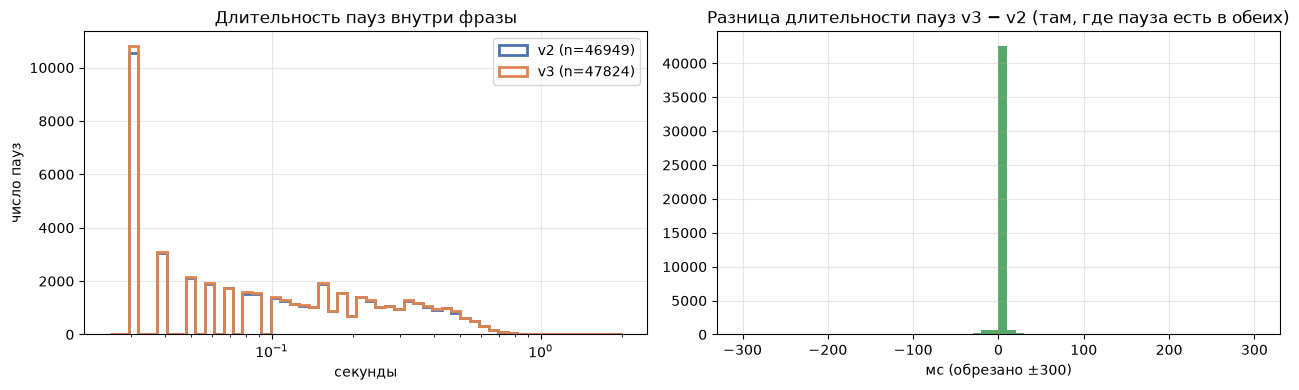

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.logspace(np.log10(0.025), np.log10(2), 55)
for t, name, color in [(tab2, "v2", BLUE), (tab3, "v3", ORANGE)]:
    d = t[(t.is_last_word == 0) & (t.is_pause_after == 1)].pause_duration
    axes[0].hist(d, bins=bins, histtype="step", linewidth=2, label=f"{name} (n={len(d)})", color=color)
axes[0].set_xscale("log")
axes[0].set(title="Длительность пауз внутри фразы", xlabel="секунды", ylabel="число пауз")
axes[0].legend()
diff = (b.pause_duration.values[m][both] - a.pause_duration.values[m][both]) * 1000
axes[1].hist(diff.clip(-300, 300), bins=60, color=GREEN)
axes[1].set(title="Разница длительности пауз v3 − v2 (там, где пауза есть в обеих)", xlabel="мс (обрезано ±300)")
plt.tight_layout()
plt.show()

In [55]:
# какие слова раньше были нераспознанными и стали распознанными
bad_before = set(u2.index[u2.spn > 0])
fixed = bad_before & set(u3.index[u3.spn == 0])
still = bad_before & set(u3.index[u3.spn > 0])
print(f"Фраз с spn в v2: {len(bad_before)}; в v3 у них нет spn: {len(fixed)} ({len(fixed) / len(bad_before):.1%}), остался: {len(still)}")
new_spn = set(u3.index[u3.spn > 0]) - bad_before
print(f"Фраз с spn в v3, которых не было в v2: {len(new_spn)}")
w_spn = tab3[tab3.spn == 1].label_raw.map(lambda x: pp.split_token(x)[1].lower()).value_counts()
print("Слова со spn в v3 (топ):", w_spn.head(15).to_dict())

Фраз с spn в v2: 1970; в v3 у них нет spn: 1957 (99.3%), остался: 13
Фраз с spn в v3, которых не было в v2: 1
Слова со spn в v3 (топ): {"о'кей": 4, 'неисчерпаемая': 2, "о'коннор": 2, 'летосчисление': 1, 'неисчерпаемости': 1, 'бесчинствуют': 1, 'бесчисленным': 1, 'неисчислимое': 1, 'исчерпана': 1}


Почти все фразы с `spn` (99 %) теперь выровнены нормально. Оставшиеся нераспознанные слова - с буквосочетанием «сч» («летосчисление», «бесчинствуют», «неисчислимое») и
апострофом («о'кей»). Причина в самой модели MFA 3.1.0: произношение «сч» записано в словаре как `ɕ tɕ`, но фонемы `ɕ` нет среди 93 фонем акустической модели
(там только долгая `ɕː`), и MFA молча отбрасывает такие произношения (предупреждение «62 pronunciations ... were ignored»). Исправление - заменить `ɕ tɕ` на `ɕː` в словаре; здесь не сделано,
так как затрагивает единицы фраз.

### 6.4. Влияние на предиктор пауз

Повторим протокол раздела 4 на новой разметке: обучение на `train`, порог по валидации, замеры на `test` в двух протоколах. «Обучение v2 → test v3» - модель из раздела 4 на
новой разметке (токены теперь без разрезанных дефисов).

In [56]:
def pipeline(tab, spn_by_id=None):
    t, _ = add_quality(tab, spn_by_id)
    tr = t[t.set == "train"].reset_index(drop=True)
    te = t[t.set == "test"].reset_index(drop=True)
    fo = tr.id.str.split("_").str[0].astype(int) % 5
    va, fi = tr[fo == 1].reset_index(drop=True), tr[fo != 1].reset_index(drop=True)
    model = train_model(fi, "raw", "raw")
    thr = best_threshold(va, predict_proba(model, va)[0])
    final_m = train_model(tr, "raw", "raw")
    proba, dur = predict_proba(final_m, te)
    off, cln = report(te, proba, dur, thr)
    return {"порог": thr, "F1 офиц.": off["F1"], "MAE офиц.": off["MAE"], "F1 чистый": cln["F1"], "MAE чистый": cln["MAE"],
            "слов в test": off["слов"]}, final_m, thr, te

res2, model2, thr2, te2 = pipeline(pause_df, ph_spn)
res3, model3, thr3, te3 = pipeline(v3_raw)
proba_c, dur_c = predict_proba(model2, te3)
off_c, cln_c = report(te3, proba_c, dur_c, thr2)
downstream = pd.DataFrame({
    "обучение v2 → test v2": res2,
    "обучение v2 → test v3": {"порог": thr2, "F1 офиц.": off_c["F1"], "MAE офиц.": off_c["MAE"], "F1 чистый": cln_c["F1"],
                              "MAE чистый": cln_c["MAE"], "слов в test": off_c["слов"]},
    "обучение v3 → test v3": res3}).T
downstream.round(3)

,порог,F1 офиц.,MAE офиц.,F1 чистый,MAE чистый,слов в test
обучение v2 → test v2,0.375,0.754,0.108,0.778,0.115,45127.0
обучение v2 → test v3,0.375,0.759,0.108,0.783,0.118,45951.0
обучение v3 → test v3,0.400,0.760,0.108,0.789,0.118,45951.0


Метрики практически не изменились (F1 0,754 → 0,760, MAE 0,108 везде): различия в пределах 1 п.п. сопоставимы с шумом, тем более что `test` у разметок немного различается (в v3 на 824 слова больше).
Для предиктора пауз это ожидаемо: статистика пауз осталась прежней. Польза перезапуска - в **данных для следующих работ**: полный охват корпуса, фонемная разметка
без нераспознанных слов (в v2 каждая десятая фраза содержала `spn`, а это прямая помеха обучению G2P и акустической модели в лабораторных №3–4) и единая токенизация с предиктором.

### 6.5. Микропаузы: проблема осталась

Пик 30 мс (22,6 % пауз) - артефакт, а не следствие неудачной разметки слов. Повторим проверку по сигналу из раздела 2.4 на новой разметке.

In [57]:
def energy_of(tab, n=300):
    tt = tab.copy()
    tt["pend"] = tt.start + tt.duration
    sil_ = tt[(tt.is_last_word == 0) & (tt.is_pause_after == 1)]
    out = []
    for cname, (lo, hi) in classes.items():
        pool = sil_[(sil_.pause_duration >= lo) & (sil_.pause_duration < hi)]
        for _, r in pool.sample(min(n, len(pool)), random_state=0).iterrows():
            sr, x = get_wav(r.id)
            a_, b_ = int((r.pend + 0.005) * sr), int((r.pend + r.pause_duration - 0.005) * sr)
            if b_ - a_ < 10:
                continue
            out.append({"класс": cname, "дБ": rms_db(x[a_:b_], np.sqrt(np.mean(x ** 2)))})
        wav_cache.clear()
    return pd.DataFrame(out)

energy3 = energy_of(tab3)
cmp_energy = pd.DataFrame({
    "v2, медиана дБ": energy.groupby("класс").дБ.median().loc[order_c],
    "v3, медиана дБ": energy3.groupby("класс").дБ.median().loc[order_c],
    "v2, доля ярче −20 дБ": energy.groupby("класс").дБ.apply(lambda s: (s > -20).mean()).loc[order_c],
    "v3, доля ярче −20 дБ": energy3.groupby("класс").дБ.apply(lambda s: (s > -20).mean()).loc[order_c]})
cmp_energy.round(2)

,"v2, медиана дБ","v3, медиана дБ","v2, доля ярче −20 дБ","v3, доля ярче −20 дБ"
класс,,,,
30 мс,-27.19,-27.90,0.20,0.22
40–60 мс,-33.61,-34.81,0.09,0.08
60–100 мс,-38.63,-38.15,0.04,0.03
100–200 мс,-39.80,-40.82,0.02,0.02
> 300 мс,-42.27,-43.44,0.03,0.00


Микропаузы в v3 ведут себя так же, как в v2: медиана −28 дБ, каждая пятая громче −20 дБ (у настоящих пауз ≥ 100 мс - около −40 дБ и 0–3 %). Значит, пик задаётся самим выравнивателем
(минимальная длина интервала тишины и шаг 10 мс), а не словарём.

Проверим, не поможет ли встроенный в MFA режим `--fine_tune` (дополнительное уточнение границ). Прогон на первых 600 фразах:

In [58]:
import os
from pathlib import Path

if Path("../../data/mfa/align_subset_ft").exists():
    ft = rm.build_table(Path("../../data/mfa/align_subset_ft"), Path("../../data/mfa/table_ft.csv"))
    base = v3_raw[v3_raw.id.isin(ft.id.unique())]
    rows = {}
    for name, t in [("MFA по умолчанию", base), ("MFA с --fine_tune", ft)]:
        inner = t[(t.is_last_word == 0) & (t.is_pause_after == 1)].pause_duration
        rows[name] = {"фраз": t.id.nunique(), "пауз": len(inner), "пауз ровно 30 мс, %": (inner.sub(0.03).abs() < 0.0005).mean() * 100,
                      "пауз на сетке 10 мс, %": (inner.mul(100).sub(inner.mul(100).round()).abs() < 1e-6).mean() * 100}
    os.remove("../../data/mfa/table_ft.csv")
    display(pd.DataFrame(rows).T.round(1))
else:
    print("Папка data/mfa/align_subset_ft не найдена: запустите `python realign_mfa.py align --subset 600 --name align_subset_ft --fine_tune`")

600 utterances, 3484 words; skipped: 21254


,фраз,пауз,"пауз ровно 30 мс, %","пауз на сетке 10 мс, %"
MFA по умолчанию,600.0,1359.0,37.4,100.0
MFA с --fine_tune,600.0,1397.0,32.8,100.0


`--fine_tune` не убирает ни пик 30 мс (доля падает с 37 % до 33 % на этом подмножестве, но остаётся доминирующей), ни сетку: длительности по-прежнему кратны 10 мс.
Поэтому основной результат перезапуска - не новая «лучшая» статистика пауз, а **исправление охвата и нераспознанных слов**; для борьбы с микропаузами нужен другой метод (другой выравниватель,
дообучение акустической модели на корпусе или постобработка - например, отбрасывание пауз ≤ 50 мс, как мы делаем в «чистом» протоколе).

## Выводы

| Показатель | Порог (обновлённый) | `test`, официальный | `test`, чистый |
|---|---|---|---|
| F1 для `is_pause_after` | ≥ 0,70 | **0,754** | 0,778 |
| MAE длительности, с | < 0,120 | **0,108** | 0,115 |

- **Данные:** разметка MFA содержит много артефактов (микропаузы 30 мс, 10 % фраз с нераспознанными словами, 1,3 % фраз потеряно из-за скобок).
  Для оценки мы используем «чистый» `test`, для обучения - все данные: удаление плохих фраз из обучения ничего не даёт.
- **Метод:** два градиентных бустинга (вероятность паузы и её длительность) над признаками пунктуации, позиции в предложении, соседних слов и морфологии pymorphy3.
  Бейзлайн по пунктуации уже даёт F1 0,715; модель добавляет +4 п.п., закрывая часть пауз без знаков и отсеивая часть пауз на запятых.
- **Решение, отличающееся от плана:** по итогам эксперимента (раздел 4.4) модель обучается на официальных метках, а не на паузах ≥ 60 мс.
- **Предел задачи:** см. сводку в конце раздела 4.9 - согласие диктора с самим собой (F1 0,65, отклонение 0,16 с) показывает, что высокие абсолютные ошибки
  - свойство задачи, а не недостаток модели.

- **Дополнительные задания.**
  - *Токенизатор* (раздел 5): `tokenize_text` воспроизводит токены MFA в 98,5 % фраз, деление по пробелу - в 69 %; на качество предиктора это даёт ≈ 3 п.п. F1.
  - *Улучшение разметки* (раздел 6): выравнивание по нормализованному тексту с расширенным словарём вернуло 284 потерянные фразы и почти убрало нераспознанные слова
    (фраз с `spn` - с 9,1 % до 0,06 %). Статистика пауз и качество предиктора не изменились; пик микропауз 30 мс остался - он определяется самим выравнивателем.
    Новая разметка: `data/mfa/align_v3/` (TextGrid) и `labs/lab2_pauses/data/RUSLAN_pause_metadata_v3.csv`.